# VEP

Variant Effect Prediction (VEP) using Protein Language Models.

In [28]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import os
# only load this one time per session
if 'NOTEBOOK_INITIALIZED' not in globals():
    os.chdir(os.path.dirname(os.path.abspath('.')))
    NOTEBOOK_INITIALIZED = True


import src.utils as utils
import src.config as config
import src.haplosaurus as hs
import src.ESM as ESM
import src.ESM_predict as ESMp
import src.gprofiler as gp
import src.vep_pipeline as vp
import src.vep_analysis as va
import src.vep_metrics as vm
import src.proteingym as pg 
import src.ensembl_rest as er
import src.biopython as bp

pd.set_option('display.max_columns', None)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Import data

### Candidate proteins
A curated list of proteins that clinically relevant and incompletely penetrant across different ethnic populations.


### ProteinGym clinical mutations
Import set of clinical variants (substitutions and indels) to use for perturbing the wild-type protein sequences *in silico*.

In [9]:
proteins_df = pg.merge_resources(rows_per_id=None)
proteins_df

ProteinGym: Gathering resources:   0%|          | 0/2 [00:00<?, ?it/s]

,protein,RefSeq peptide ID,source_file,source_type,experiment_id,genename,ENSG,ENST,ENSP
0,NP_006061.2,NP_006061,/home/schilder/.cache/ProteinGym/clinical_Prot...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_006061.2,TFG,ENSG00000114354,ENST00000620299,ENSP00000479981
1,NP_006061.2,NP_006061,/home/schilder/.cache/ProteinGym/clinical_Prot...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_006061.2,TFG,ENSG00000114354,ENST00000490574,ENSP00000419960
2,NP_001341569.1,NP_001341569,/home/schilder/.cache/ProteinGym/clinical_Prot...,clinical_ProteinGym_indels,clinical_ProteinGym_indels/NP_001341569.1,NaN,NaN,NaN,NaN
3,NP_003313.3,NP_003313,/home/schilder/.cache/ProteinGym/clinical_Prot...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_003313.3,TULP1,ENSG00000112041,ENST00000229771,ENSP00000229771
4,NP_001116102.1,NP_001116102,/home/schilder/.cache/ProteinGym/clinical_Prot...,clinical_ProteinGym_indels,clinical_ProteinGym_indels/NP_001116102.1,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
4774,UPI0001E8F37E,UPI0001E8F37E,/home/schilder/.cache/ProteinGym/clinical_Prot...,clinical_ProteinGym_indels,clinical_ProteinGym_indels/UPI0001E8F37E,NaN,NaN,NaN,NaN
4775,UPI0001E92A31,UPI0001E92A31,/home/schilder/.cache/ProteinGym/clinical_Prot...,clinical_ProteinGym_indels,clinical_ProteinGym_indels/UPI0001E92A31,NaN,NaN,NaN,NaN
4776,NP_003163.1,NP_003163,/home/schilder/.cache/ProteinGym/clinical_Prot...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_003163.1,SURF1,ENSG00000148290,ENST00000371974,ENSP00000361042
4777,NP_000170.1,NP_000170,/home/schilder/.cache/ProteinGym/clinical_Prot...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_000170.1,MSH6,ENSG00000116062,ENST00000540021,ENSP00000446475


In [10]:
candidate_proteins = utils.get_candidate_proteins()
candidate_proteins['protein'] = candidate_proteins['RefSeq Protein']
# candidate_proteins = er.map_ids(df=candidate_proteins,
#                                 input_col="RefSeq Protein")
candidate_proteins = pg.map_resources(df=candidate_proteins)
candidate_proteins

Mapping Proteingym IDs
Loading mapping file from /home/schilder/.cache/ProteinGym/proteingym_id_map_693de35055033c431bc1452512841718.csv.gz


,Gene,Protein Common Name,RefSeq Protein,RefSeq Transcript,RefSeq Protein Stable,protein,genename,ENSG,ENST,ENSP
0,G6PD,Glucose-6-phosphate 1-dehydrogenase,NP_001346945.1,NM_001360016.2,NP_001346945,NP_001346945.1,NaN,NaN,NaN,NaN
1,HFE,Homeostatic Iron Regulator,NP_000401.1,NM_000410.4,NP_000401,NP_000401.1,HFE,ENSG00000010704,ENST00000357618,ENSP00000417404
2,CFTR,Cystic Fibrosis Transmembrane Conductance Regu...,NP_000483.3,NM_000492.4,NP_000483,NP_000483.3,CFTR,ENSG00000001626,ENST00000003084,ENSP00000003084
3,BRCA1,Breast Cancer Type 1 Susceptibility Protein,NP_009225.1,NM_007294.4,NP_009225,NP_009225.1,BRCA1,ENSG00000012048,ENST00000357654,ENSP00000350283
4,BRCA1,Breast Cancer Type 1 Susceptibility Protein,NP_009225.1,NM_007294.4,NP_009225,NP_009225.1,BRCA1,ENSG00000012048,ENST00000352993,ENSP00000312236
5,BRCA2,Breast Cancer Type 2 Susceptibility Protein,NP_000050.3,NM_000059.4,NP_000050,NP_000050.3,NaN,NaN,NaN,NaN
6,F5,Coagulation Factor V,NP_000121.2,NM_000130.5,NP_000121,NP_000121.2,F5,ENSG00000198734,ENST00000367797,ENSP00000356771
7,HBB,Hemoglobin Subunit Beta,NP_000509.1,NM_000518.5,NP_000509,NP_000509.1,HBB,ENSG00000244734,ENST00000335295,ENSP00000333994
8,SERPINA1,Alpha-1 Antitrypsin,NP_000286.3,NM_000295.5,NP_000286,NP_000286.3,SERPINA1,ENSG00000197249,ENST00000440909,ENSP00000390299
9,LDLR,Low-Density Lipoprotein Receptor,NP_000518.1,NM_000527.5,NP_000518,NP_000518.1,LDLR,ENSG00000130164,ENST00000558518,ENSP00000454071


### Haplotypes
Import haplotype sequences from Haplosaurus. 
These are the wild-type sequences for each protein that occurs within the 1000 Genomes Project.






In [11]:
# Download and import haplotypes (includes lots of other data/metadata)
haplotypes = hs.get_haplotypes(#tx_ids=candidate_proteins["ENST"],
                              #  use_protein_ids=True, 
                               
                            #    max_tx_ids=10, # Can limit to a subset of transcripts for testing
                               cache_only=True # Set to true to speed up subsequent runs by only import from cache. Set to False if you're running this for the first time.
                               )

Found haplotypes of 47325 transcripts in: '/home/schilder/.cache/ensembl_rest/haplotypes'


Getting haplotypes:   0%|          | 0/47325 [00:00<?, ?it/s]

KeyboardInterrupt: 

`filter_prot_df` provides a convenient way to filter the ProteinGym mutations according to which ones are present in the 1KG haplotypes data,   
as well as which ones are present in the candidate proteins.

It will automatically figure out which `proteins_df` columns in it should be filtering on according to the prefixes in the `protein_ids` ('ENSP' or 'ENST' or 'protein') and `haplotypes` ('ENSP' or 'ENST').

It can also filter by the types of mutations you wish to inject during the VEP procedure (see the 'source_type' column for available options).

The final product is the filtered `proteins_df`, which we store as a new DataFrame `prot_df`.

In [6]:
prot_df = vp.filter_prot_df(proteins_df,
#                             protein_ids=candidate_proteins["ENSP"],
                            haplotypes=haplotypes,
                            source_types="clinical_ProteinGym_substitutions",
                            )
prot_df

Filtering by 1 source types
Filtering by ENST haplotypes


Getting haplotype sequences:   0%|          | 0/557 [00:00<?, ?it/s]

  0%|          | 0/557 [00:00<?, ?it/s]

Filtered 10 / 192 proteins due to sequence length mismatch
Returning 182 unique proteins


,protein,RefSeq peptide ID,source_file,source_type,experiment_id,genename,ENSG,ENST,ENSP,proteingym_seq_len,haplosaurus_seq_len,proteingym_haplosaurus_seq_sim,proteingym_haplosaurus_seq_identical
18,NP_004437.2,NP_004437,/home/schilder/.cache/ProteinGym/clinical_Prot...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_004437.2,EPRS,ENSG00000136628,ENST00000366923,ENSP00000355890,[1512],[1512],1.0,True
40,NP_065873.2,NP_065873,/home/schilder/.cache/ProteinGym/clinical_Prot...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_065873.2,KCNT1,ENSG00000107147,ENST00000371757,ENSP00000360822,[1235],[1235],1.0,True
44,NP_115791.3,NP_115791,/home/schilder/.cache/ProteinGym/clinical_Prot...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_115791.3,CARD11,ENSG00000198286,ENST00000396946,ENSP00000380150,[1154],[1154],1.0,True
58,NP_004619.3,NP_004619,/home/schilder/.cache/ProteinGym/clinical_Prot...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_004619.3,XPC,ENSG00000154767,ENST00000285021,ENSP00000285021,[940],[940],1.0,True
103,NP_060269.3,NP_060269,/home/schilder/.cache/ProteinGym/clinical_Prot...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_060269.3,TMEM260,ENSG00000070269,ENST00000261556,ENSP00000261556,[707],[707],1.0,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4653,NP_002520.2,NP_002520,/home/schilder/.cache/ProteinGym/clinical_Prot...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_002520.2,NTRK1,ENSG00000198400,ENST00000524377,ENSP00000431418,[796],[796],1.0,True
4686,NP_000084.3,NP_000084,/home/schilder/.cache/ProteinGym/clinical_Prot...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_000084.3,COL5A1,ENSG00000130635,ENST00000371817,ENSP00000360882,[1838],[1838],1.0,True
4701,NP_000144.2,NP_000144,/home/schilder/.cache/ProteinGym/clinical_Prot...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_000144.2,GALC,ENSG00000054983,ENST00000261304,ENSP00000261304,[685],[685],1.0,True
4703,NP_000292.1,NP_000292,/home/schilder/.cache/ProteinGym/clinical_Prot...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_000292.1,PLG,ENSG00000122194,ENST00000308192,ENSP00000308938,[810],[810],1.0,True


We also need to remove any suspicious proteins that have a different reference sequence lengths in the Haplosaurus haplotypes and the ProteinGym mutations   
(which suggests that the ProteinGym proteins are not exactly the same as the Haplosaurus ones).

In [7]:
prot_df = vp.add_sequence_checks(prot_df,
                                  haplotypes=haplotypes)
prot_df = prot_df.loc[prot_df['proteingym_haplosaurus_seq_identical'] == True]
prot_df

,protein,RefSeq peptide ID,source_file,source_type,experiment_id,genename,ENSG,ENST,ENSP,proteingym_seq_len,haplosaurus_seq_len,proteingym_haplosaurus_seq_sim,proteingym_haplosaurus_seq_identical
18,NP_004437.2,NP_004437,/home/schilder/.cache/ProteinGym/clinical_Prot...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_004437.2,EPRS,ENSG00000136628,ENST00000366923,ENSP00000355890,[1512],[1512],1.0,True
40,NP_065873.2,NP_065873,/home/schilder/.cache/ProteinGym/clinical_Prot...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_065873.2,KCNT1,ENSG00000107147,ENST00000371757,ENSP00000360822,[1235],[1235],1.0,True
44,NP_115791.3,NP_115791,/home/schilder/.cache/ProteinGym/clinical_Prot...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_115791.3,CARD11,ENSG00000198286,ENST00000396946,ENSP00000380150,[1154],[1154],1.0,True
58,NP_004619.3,NP_004619,/home/schilder/.cache/ProteinGym/clinical_Prot...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_004619.3,XPC,ENSG00000154767,ENST00000285021,ENSP00000285021,[940],[940],1.0,True
103,NP_060269.3,NP_060269,/home/schilder/.cache/ProteinGym/clinical_Prot...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_060269.3,TMEM260,ENSG00000070269,ENST00000261556,ENSP00000261556,[707],[707],1.0,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4653,NP_002520.2,NP_002520,/home/schilder/.cache/ProteinGym/clinical_Prot...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_002520.2,NTRK1,ENSG00000198400,ENST00000524377,ENSP00000431418,[796],[796],1.0,True
4686,NP_000084.3,NP_000084,/home/schilder/.cache/ProteinGym/clinical_Prot...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_000084.3,COL5A1,ENSG00000130635,ENST00000371817,ENSP00000360882,[1838],[1838],1.0,True
4701,NP_000144.2,NP_000144,/home/schilder/.cache/ProteinGym/clinical_Prot...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_000144.2,GALC,ENSG00000054983,ENST00000261304,ENSP00000261304,[685],[685],1.0,True
4703,NP_000292.1,NP_000292,/home/schilder/.cache/ProteinGym/clinical_Prot...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_000292.1,PLG,ENSG00000122194,ENST00000308192,ENSP00000308938,[810],[810],1.0,True


## Run VEP pipeline

Run the VEP pipeline which iterates VEP over a series of models/proteins/haplotypes/variant source types/scoring strategies. 

The results are saved in a folder structure:  
{save_dir}/  
    {model}/  
    {protein_id}/  
        {haplotype}/  
        {source_type}/  
            {scoring_strategy1}.csv.gz  
            {scoring_strategy2}.csv.gz  
            {scoring_strategy3}.csv.gz  

List all models currently supported by the VEP pipeline.

In [8]:
vp.list_models(as_list=False)

Available models:
- esm1_t12_85M_UR50S
- esm1_t34_670M_UR100
- esm1_t34_670M_UR50D
- esm1_t34_670M_UR50S
- esm1_t6_43M_UR50S
- esm1b_t33_650M_UR50S
- esm1v_t33_650M_UR90S
- esm1v_t33_650M_UR90S_1
- esm1v_t33_650M_UR90S_2
- esm1v_t33_650M_UR90S_3
- esm1v_t33_650M_UR90S_4
- esm1v_t33_650M_UR90S_5
- esm2
- esm2_t12_35M_UR50D
- esm2_t30_150M_UR50D
- esm2_t33_650M_UR50D
- esm2_t36_3B_UR50D
- esm2_t48_15B_UR50D
- esm2_t6_8M_UR50D
- esm_if1_gvp4_t16_142M_UR50
- esm_msa1_t12_100M_UR50S
- esm_msa1b_t12_100M_UR50S
- esmfold_structure_module_only_150M
- esmfold_structure_module_only_150M_270K
- esmfold_structure_module_only_15B
- esmfold_structure_module_only_35M
- esmfold_structure_module_only_35M_270K
- esmfold_structure_module_only_3B
- esmfold_structure_module_only_3B_270K
- esmfold_structure_module_only_650M
- esmfold_structure_module_only_650M_270K
- esmfold_structure_module_only_8M
- esmfold_structure_module_only_8M_270K
- esmfold_v0
- esmfold_v1


Run VEP pipeline and store the results in `save_dir`.

In [ ]:
import torch
torch.cuda.set_device(1)

save_paths = vp.vep_pipeline(
    # prot_df = prot_df,
    # haplotypes = haplotypes,
    # save_dir = os.path.join(config.DATA_DIR,"1KG","vep"),
    models = [
#         "esm1_t6_43M_UR50S",
#           "esm1_t34_670M_UR50D",
#           "esm1v_t33_650M_UR90S_1",
#           "esm1b_t33_650M_UR50S",
        #   "esm2_t12_35M_UR50D",
        #   "esm2_t33_650M_UR50D",
        #   "esm2_t36_3B_UR50D"
          "esm2_t48_15B_UR50D",
#           "esmfold_v1"
             ],
    scoring_strategies = [
        "wt-marginals", 
        "masked-marginals",
#         "pseudo-ppl" # Takes much longer to run
        ],
    enable_data_parallel=False,
    source_types = ["clinical_ProteinGym_substitutions"],
    verbose = False
)

print(len(save_paths),"results files generated.")

## Explore VEP results

Automatically search for, import, and merge the VEP results. 
You can import only subsets of results by setting the save_dir to a lower level, e.g.: 
`os.path.join(save_dir,{model_name},{protein_id}})`

Setting `add_metadata=True` will automatically import additional variant-level metadata (collected from ProteinGym) which will be helpful for downstream plotting/analysis tasks.

### Merge VEP results files
Merge individual VEP files into one large dataframe.

In [8]:
vep_files = va.list_vep_files(as_df=True)

No save_dir provided, using: /home/schilder/projects/data/1KG/vep


Finding VEP files:   0%|          | 0/3 [00:00<?, ?it/s]

Found 364376 parquet files in /home/schilder/projects/data/1KG/vep
Unique values:
>> model_location: 7
scoring_strategy: 3
variant_set: 1
haplotype: 85106
protein: 2142


In [10]:
vep_df = va.merge_vep(add_metadata=True, 
                      scoring_strategy=["masked-marginals"],
                      vep_files=vep_files.loc[vep_files['model_location']=="esm2_t33_650M_UR50D"]
                          )
vep_df.head()

No save_dir provided, using: /home/schilder/projects/data/1KG/vep
Found 57984 masked-marginals parquet files


Reading files:   0%|          | 0/57984 [00:00<?, ?it/s]

Concatenating VEP dataframes
Loading ==> /home/schilder/projects/data/haplosaurus/tx_id_map.pkl


Loading '/home/schilder/projects/data/haplosaurus/tx_id_map.pkl': 100%|██████████| 1.70M/1.70M [00:00<00:00, 5.34GB/s]
<string>:83: DtypeWarning: Columns (0,47) have mixed types. Specify dtype option on import or set low_memory=False.


VEP dataframe shape: (2028077, 72)


,haplotype,protein,protein_sequence,mutant,mutated_sequence,DMS_bin_score,VEP,scoring_strategy,is_ref,model_location,variant_set,ENSP,ENST,mutant_in_haplotype,#CHROM,POS,ID,REF,ALT,QUAL,FILTER,#Uploaded_variation,Location,Allele,Gene,Feature,Feature_type,Consequence,cDNA_position,CDS_position,Protein_position,Amino_acids,Codons,Existing_variation,IMPACT,DISTANCE,STRAND,FLAGS,REFSEQ_MATCH,REFSEQ_OFFSET,GIVEN_REF,USED_REF,BAM_EDIT,HGVSc,HGVSp,HGVS_OFFSET,AF_ESP,AF_EXAC,ALLELEID,CLNDISDB,CLNDN,CLNHGVS,CLNREVSTAT,CLNSIG,CLNSIGCONF,CLNVC,CLNVCSO,GENEINFO,MC,ORIGIN,RS,AF_TGP,CLNVI,CLNDISDBINCL,CLNDNINCL,CLNSIGINCL,EVH_epistatic,EVH_independent,ESM1V_ensemble_mean,Tranception,model_count,clinsig
0,ENSP00000262186:1032R>Q,NP_000229.1,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,L1045F,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,Benign,-3.635069,masked-marginals,False,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000262186,ENST00000262186,False,7,150947347,67473,G,A,.,PASS,67473,7:150947347,A,3757,NM_000238.4,Transcript,missense_variant,3541,3133,1045,L/F,Ctc/Ttc,-,MODERATE,-,-1,-,-,-,G,G,-,NM_000238.4:c.3133C>T,NP_000229.1:p.Leu1045Phe,-,NaN,0.00000,78369,"MedGen:CN230736|EFO:EFO_0004269,Human_Phenotyp...",Cardiovascular_phenotype|Cardiac_arrhythmia|Co...,NC_000007.14:g.150947347G>A,"criteria_provided,_multiple_submitters,_no_con...",Benign,NaN,single_nucleotide_variant,SO:0001483,KCNH2:3757,SO:0001583|missense_variant,1,199473025.0,NaN,ClinGen:CA008015,NaN,NaN,NaN,NaN,NaN,-6.731237,-0.021689,6,benign
1,ENSP00000262186:1032R>Q,NP_000229.1,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,D1003Y,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,Pathogenic,-1.670645,masked-marginals,False,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000262186,ENST00000262186,False,7,150947473,200516,C,A,.,PASS,200516,7:150947473,A,3757,NM_000238.4,Transcript,missense_variant,3415,3007,1003,D/Y,Gac/Tac,-,MODERATE,-,-1,-,-,-,C,C,-,NM_000238.4:c.3007G>T,NP_000229.1:p.Asp1003Tyr,-,NaN,NaN,197155,MedGen:CN517202,not_provided,NC_000007.14:g.150947473C>A,"criteria_provided,_single_submitter",Likely_pathogenic,NaN,single_nucleotide_variant,SO:0001483,KCNH2:3757,"SO:0001583|missense_variant,SO:0001619|non-cod...",1,794728402.0,NaN,ClinGen:CA007791,NaN,NaN,NaN,NaN,NaN,-2.509515,-0.039753,6,likely_path
2,ENSP00000262186:1032R>Q,NP_000229.1,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,N996I,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,Pathogenic,-4.619007,masked-marginals,False,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000262186,ENST00000262186,False,7,150947493,67458,T,A,.,PASS,67458,7:150947493,A,3757,NM_000238.4,Transcript,missense_variant,3395,2987,996,N/I,aAc/aTc,-,MODERATE,-,-1,-,-,-,T,T,-,NM_000238.4:c.2987A>T,NP_000229.1:p.Asn996Ile,-,NaN,NaN,78354,"MONDO:MONDO:0019171,MedGen:C1141890,OMIM:PS192...",Congenital_long_QT_syndrome|not_provided|Long_...,NC_000007.14:g.150947493T>A,"criteria_provided,_multiple_submitters,_no_con...",Pathogenic/Likely_pathogenic,NaN,single_nucleotide_variant,SO:0001483,KCNH2:3757,"SO:0001583|missense_variant,SO:0001619|non-cod...",1,199473018.0,NaN,ClinGen:CA007728|UniProtKB:Q12809#VAR_068285,NaN,NaN,NaN,NaN,NaN,-5.869637,-0.057342,6,likely_path
3,ENSP00000262186:1032R>Q,NP_000229.1,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,E978K,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,Benign,-0.514701,masked-marginals,False,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000262186,ENST00000262186,False,7,150947639,67453,C,T,.,PASS,67453,7:150947639,T,3757,NM_000238.4,Transcript,missense_variant,3340,2932,978,E/K,Gag/Aag,-,MODERATE,-,-1,-,-,-,C,C,-,NM_000238.4:c.2932G>A,NP_000229.1:p.Glu978Lys,-,0.00008,0.00039,78349,"EFO:EFO_0004269,Human_Phenotype_Ontology:HP:00...",Cardiac_arrhythmia|Cardiovascular_phenotype|no...,NC_000007.14:g.150947639C>T,"criteria_provided,_multiple_submitters,_no_con...",Likely_benign,NaN,single_nucleotide_variant,SO:0001483,K

In [3]:
# Get proteins where VEP is 0
print(vep_df.loc[vep_df['VEP']==0]['protein'].nunique())

# Get proteins where VEP is NA
print(vep_df.loc[vep_df['VEP'].isna()]['protein'].nunique())

222
611


In [5]:
vep_df.groupby(['scoring_strategy'])['VEP'].describe()

,count,mean,std,min,25%,50%,75%,max
scoring_strategy,,,,,,,,
masked-marginals,5063079.0,-2.824699,3.957131,-32.050919,-4.965721,-1.159187,-0.085693,9.393782


In [6]:
print(vep_df.shape)
print(vep_df.model_location.nunique(),"model(s)")
print(vep_df.protein.nunique(),"protein(s)")
print(vep_df.haplotype.nunique(),"haplotypes(s)")
print((vep_df.protein + '_' + vep_df.mutant).nunique(),"mutantation(s)")
print(vep_df.scoring_strategy.nunique(),"scoring strategy(ies)")

vep_df.head()

(5089027, 72)
6 model(s)
2142 protein(s)
85106 haplotypes(s)
53417 mutantation(s)
1 scoring strategy(ies)


,haplotype,protein,protein_sequence,mutant,mutated_sequence,DMS_bin_score,VEP,scoring_strategy,is_ref,model_location,variant_set,ENSP,ENST,mutant_in_haplotype,#CHROM,POS,ID,REF,ALT,QUAL,FILTER,#Uploaded_variation,Location,Allele,Gene,Feature,Feature_type,Consequence,cDNA_position,CDS_position,Protein_position,Amino_acids,Codons,Existing_variation,IMPACT,DISTANCE,STRAND,FLAGS,REFSEQ_MATCH,REFSEQ_OFFSET,GIVEN_REF,USED_REF,BAM_EDIT,HGVSc,HGVSp,HGVS_OFFSET,AF_ESP,AF_EXAC,ALLELEID,CLNDISDB,CLNDN,CLNHGVS,CLNREVSTAT,CLNSIG,CLNSIGCONF,CLNVC,CLNVCSO,GENEINFO,MC,ORIGIN,RS,AF_TGP,CLNVI,CLNDISDBINCL,CLNDNINCL,CLNSIGINCL,EVH_epistatic,EVH_independent,ESM1V_ensemble_mean,Tranception,model_count,clinsig
0,ENSP00000382271:REF,NP_055800.2,MSLDFGSVALPVQNEDEEYDEEDYEREKELQQLLTDLPHDMLDDDL...,P1637L,MSLDFGSVALPVQNEDEEYDEEDYEREKELQQLLTDLPHDMLDDDL...,Benign,-0.591809,masked-marginals,True,esm2_t12_35M_UR50D,clinical_ProteinGym_substitutions,ENSP00000382271,ENST00000399334,False,15,48738304,158270,G,A,.,PASS,158270,15:48738304,A,22995,NM_014985.4,Transcript,missense_variant,5026,4910,1637,P/L,cCg/cTg,-,MODERATE,-,-1,-,-,-,G,G,-,NM_014985.4:c.4910C>T,NP_055800.2:p.Pro1637Leu,-,NaN,NaN,169125,MedGen:CN169374|MedGen:CN517202|MONDO:MONDO:00...,"not_specified|not_provided|Microcephaly_9,_pri...",NC_000015.10:g.48738304G>A,"criteria_provided,_multiple_submitters,_no_con...",Benign/Likely_benign,NaN,single_nucleotide_variant,SO:0001483,CEP152:22995,SO:0001583|missense_variant,1,368764302.0,0.00719,ClinGen:CA211086,NaN,NaN,NaN,NaN,NaN,-1.401152,NaN,3,likely_benign
1,ENSP00000382271:REF,NP_055800.2,MSLDFGSVALPVQNEDEEYDEEDYEREKELQQLLTDLPHDMLDDDL...,P1539L,MSLDFGSVALPVQNEDEEYDEEDYEREKELQQLLTDLPHDMLDDDL...,Benign,0.569122,masked-marginals,True,esm2_t12_35M_UR50D,clinical_ProteinGym_substitutions,ENSP00000382271,ENST00000399334,False,15,48738598,712165,G,A,.,PASS,712165,15:48738598,A,22995,NM_014985.4,Transcript,missense_variant,4732,4616,1539,P/L,cCa/cTa,-,MODERATE,-,-1,-,-,-,G,G,-,NM_014985.4:c.4616C>T,NP_055800.2:p.Pro1539Leu,-,0.00133,0.00041,726115,MedGen:CN517202,not_provided,NC_000015.10:g.48738598G>A,"criteria_provided,_single_submitter",Likely_benign,NaN,single_nucleotide_variant,SO:0001483,CEP152:22995,SO:0001583|missense_variant,1,145652839.0,0.00100,NaN,NaN,NaN,NaN,NaN,NaN,0.244348,NaN,3,likely_benign
2,ENSP00000382271:REF,NP_055800.2,MSLDFGSVALPVQNEDEEYDEEDYEREKELQQLLTDLPHDMLDDDL...,S1303R,MSLDFGSVALPVQNEDEEYDEEDYEREKELQQLLTDLPHDMLDDDL...,Benign,-0.843016,masked-marginals,True,esm2_t12_35M_UR50D,clinical_ProteinGym_substitutions,ENSP00000382271,ENST00000399334,False,15,48741617,1600307,G,C,.,PASS,1600307,15:48741617,C,22995,NM_014985.4,Transcript,missense_variant,4025,3909,1303,S/R,agC/agG,-,MODERATE,-,-1,-,-,-,G,G,-,NM_014985.4:c.3909C>G,NP_055800.2:p.Ser1303Arg,-,NaN,NaN,1631867,"MeSH:D030342,MedGen:C0950123|MedGen:CN517202",Inborn_genetic_diseases|not_provided,NC_000015.10:g.48741617G>C,"criteria_provided,_multiple_submitters,_no_con...",Benign/Likely_benign,NaN,single_nucleotide_variant,SO:0001483,CEP152:22995,SO:0001583|missense_variant,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.429026,NaN,3,likely_benign
3,ENSP00000382271:REF,NP_055800.2,MSLDFGSVALPVQNEDEEYDEEDYEREKELQQLLTDLPHDMLDDDL...,L1182V,MSLDFGSVALPVQNEDEEYDEEDYEREKELQQLLTDLPHDMLDDDL...,Benign,-0.811566,masked-marginals,True,esm2_t12_35M_UR50D,clinical_ProteinGym_substitutions,ENSP00000382271,ENST00000399334,False,15,48744915,1648370,G,C,.,PASS,1648370,15:48744915,C,22995,NM_014985.4,Transcript,missense_variant,3660,3544,1182,L/V,Ctt/Gtt,-,MODERATE,-,-1,-,-,-,G,G,-,NM_014985.4:c.3544C>G,NP_055800.2:p.Leu1182Val,-,NaN,NaN,1535066,"MeSH:D030342,MedGen:C0950123|MedGen:CN517202",Inborn_genetic_diseases|not_provided,NC_000015.10:g.48744915G>C,"criteria_provided,_multiple_submitters,_no_con...",Benign/Likely_benign,NaN,single_nucleotide_variant,SO:0001483,CEP152:22995,SO:0001583|missense_variant,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.925920,NaN,3,likely_benign
4,ENSP00000382271:REF,NP_055800.2,MSLDFGSVA

### Check out of frame mutants

These should all be filtered out automatically by the vep_pipeline, but just to check.

In [7]:
# Import haplotypes if not already defined
if 'haplotypes' not in locals():
    haplotypes = hs.get_haplotypes(
        tx_ids=vep_df['ENST'].unique().tolist(),
        cache_only=True
    )

# Add haplotype sequences to the VEP dataframe
vep_df = va.add_mutant_out_of_frame(vep_df, 
                                    haplotypes=haplotypes,
                                    force=True)


# Check if any haplotypes with variants that are out of frame
print(vep_df.loc[vep_df['mutant_out_of_frame']==True]['haplotype'].unique())


# Filter out variants that are out of frame, as they should not not be able to produce a VEP
# vep_df = vep_df.loc[vep_df['mutant_out_of_frame']==False]

Found haplotypes of 47325 transcripts in: '/home/schilder/.cache/ensembl_rest/haplotypes'


Getting haplotypes:   0%|          | 0/2142 [00:00<?, ?it/s]

Adding 'haplotype_sequence' column
Getting haplotype sequences


Adding reference haplotype:   0%|          | 0/2142 [00:00<?, ?it/s]

Getting haplotype sequences:   0%|          | 0/2142 [00:00<?, ?it/s]

Getting haplotype names:   0%|          | 0/2142 [00:00<?, ?it/s]

Adding 'haplotype_sequence' column
Adding 'haplotype_sequence_len' column
Adding 'mutant_out_of_frame' column
[]


In [8]:
vep_df.loc[vep_df['VEP'].isna()]['model_location'].value_counts()

model_location
esm2_t12_35M_UR50D        14714
esm1_t34_670M_UR50D        6719
esm2_t33_650M_UR50D        2930
esm1_t6_43M_UR50S           710
esm1v_t33_650M_UR90S_1      710
esm1b_t33_650M_UR50S        165
Name: count, dtype: int64

In [10]:
# haplotypes = hs.get_haplotypes(
#     cache_only=True 
#     ) 
# vep_df['protein_id'] = vep_df['haplotype'].str.split(':').str[0]

# vep_df = hs.add_haplotype_freqs(df= vep_df, 
#                                 haplotypes = haplotypes, 
#                                 haplotype_col = "haplotype")
# vep_df.head() 

In [11]:
# seq_check_df, clinsig_counts, mutant_in_haplotype = va.report_vep(vep_df)
# display(seq_check_df, clinsig_counts, mutant_in_haplotype)

## Plots: All Proteins

### Density plots

Filtered 0.5% of rows with NAs in col 'VEP'


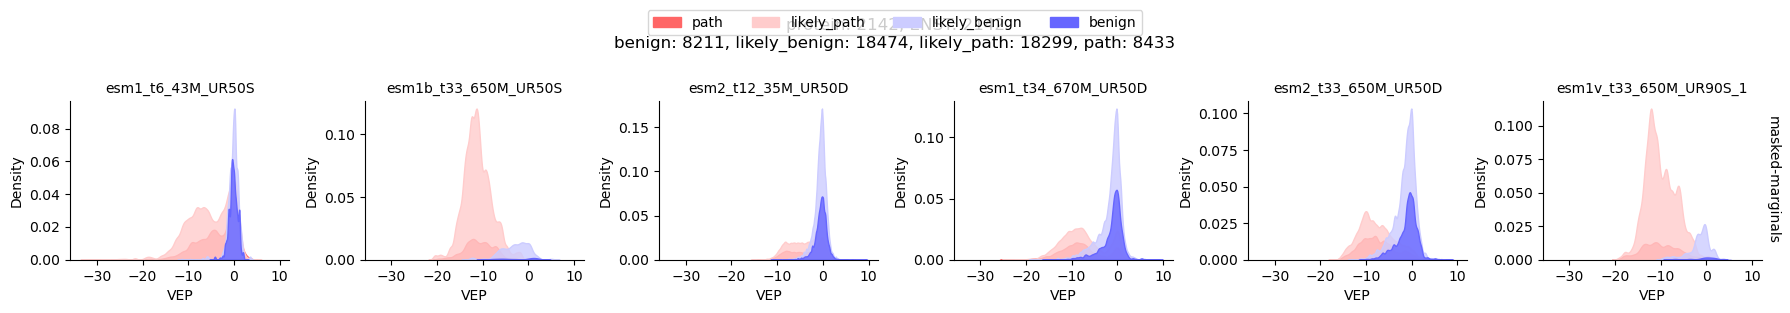

In [9]:
va.plot_vep_density(vep_df, 
                     multiple=['layer','stack','fill'][0],
                     row='scoring_strategy',
                     col='model_location',    
                     legend_y=1.1,
                     aspect=1,
                     save_path="results/plots/vep_density.png"
                     )

### Variance plots

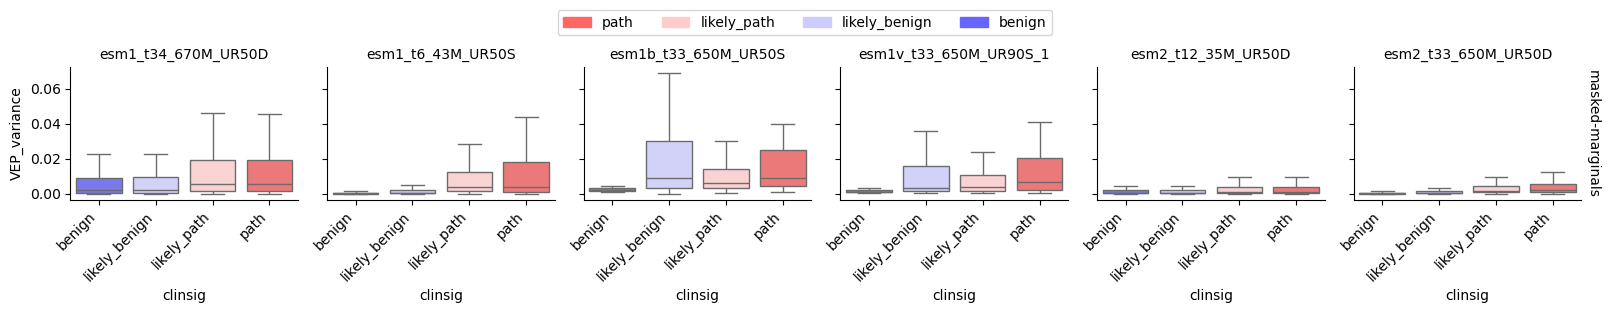

In [13]:
vep_variance = va.plot_vep_variance(vep_df, 
                                    return_df=True,
                                    showfliers=False,
                                    col='model_location',
                                    row='scoring_strategy',
                                    # save_path="results/plots/vep_variance.png",
                                    groupby_cols = ['model_location','protein',
                                                    'clinsig','mutant','scoring_strategy'],
                                    height=3
                                    )

### VEP modality plots

Within each protein, capture the modality of their distributions.

,x,y,n_peaks
0,-0.817364,0.016667,2
1,-0.815757,0.018044,2
2,-0.814150,0.019421,2
3,-0.812543,0.020798,2
4,-0.810935,0.022175,2


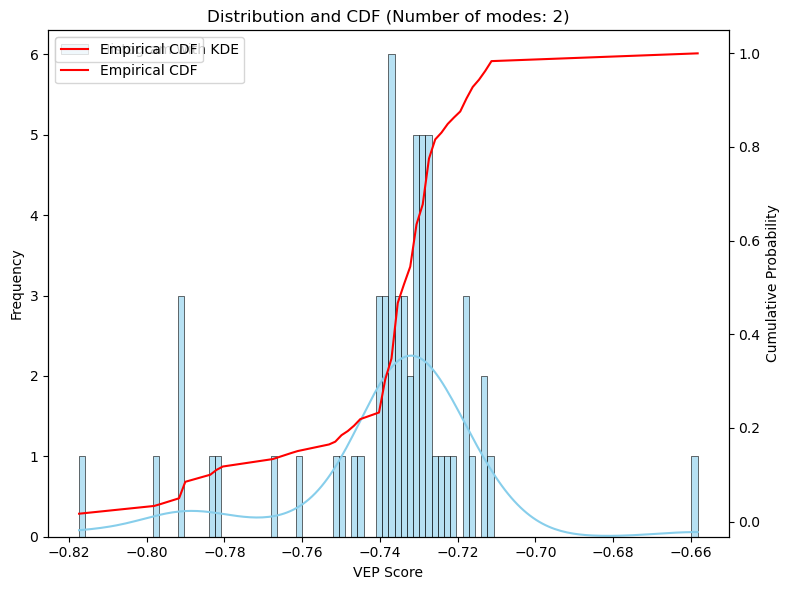

In [25]:
i = 2
dat = vep_df.dropna(subset=['VEP']).loc[(vep_df['model_location']==vep_df['model_location'].unique()[0]) &\
                                        (vep_df['protein']==vep_df['protein'].unique()[i]) &\
                                        (vep_df['scoring_strategy']=='masked-marginals')]
dat = dat.loc[dat['mutant'] == dat['mutant'].unique()[0]]
# utils.get_kde(dat['VEP'],
#                   title=f"Protein: {dat['protein'].tolist()[0]}, Scoring strategy: {dat['scoring_strategy'].tolist()[0]}",
#                   plot=True)

ecdf_df =utils.get_ecdf(dat['VEP'],
                  title=f"Protein: {dat['protein'].tolist()[0]}, Scoring strategy: {dat['scoring_strategy'].tolist()[0]}",
                  return_df=True,
                  plot=True)
ecdf_df.head()

  

In [ ]:
from tqdm import tqdm

vep_ecdf_path = 'results/vep_ecdf.tsv.gz'
if os.path.exists(vep_ecdf_path):
    print("Loading cached ECDF data")
    vep_ecdf = pd.read_csv(vep_ecdf_path, sep='\t')
else:
    
    groupby_cols = ['model_location', 'protein', 'scoring_strategy','mutant']
    vep_df['n_haplotypes'] = vep_df.groupby(groupby_cols)['haplotype'].transform('nunique')
    
    tqdm.pandas(desc="Estimating modality")
    vep_ecdf = vep_df.dropna(subset=['VEP']).groupby(groupby_cols+['n_haplotypes'])['VEP'].progress_apply(
        utils.get_ecdf, 
        return_df=True, 
        error=False
    ).reset_index()
    vep_ecdf.rename(columns={'level_5':'index'}, inplace=True)

    vep_ecdf.to_csv(vep_ecdf_path, index=False, sep='\t')

print(vep_ecdf.shape)
vep_ecdf.head()

(9203900, 9)


,model_location,protein,scoring_strategy,mutant,n_haplotypes,index,x,y,n_peaks
0,esm1_t34_670M_UR50D,NP_000008.1,masked-marginals,A101V,38,0,-4.679832,0.026316,2
1,esm1_t34_670M_UR50D,NP_000008.1,masked-marginals,A101V,38,1,-4.667343,0.026946,2
2,esm1_t34_670M_UR50D,NP_000008.1,masked-marginals,A101V,38,2,-4.654853,0.027576,2
3,esm1_t34_670M_UR50D,NP_000008.1,masked-marginals,A101V,38,3,-4.642364,0.028206,2
4,esm1_t34_670M_UR50D,NP_000008.1,masked-marginals,A101V,38,4,-4.629874,0.028836,2


NameError: name '_get_default_save_dir' is not defined

count    9.203900e+06
mean     2.041939e+00
std      3.818779e-01
min      1.000000e+00
25%      2.000000e+00
50%      2.000000e+00
75%      2.000000e+00
max      5.000000e+00
Name: n_peaks, dtype: float64


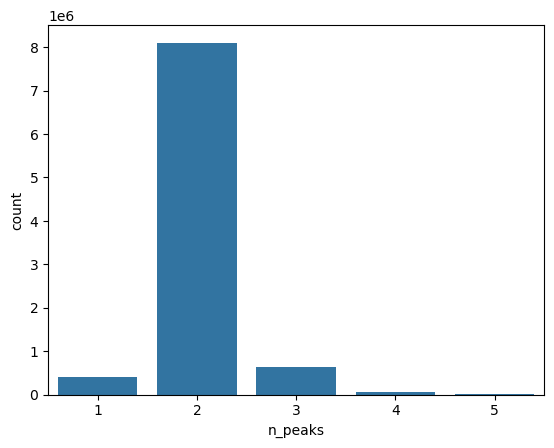

In [3]:
print(vep_ecdf['n_peaks'].describe())

import matplotlib.pyplot as plt
import seaborn as sns
sns.barplot(data=vep_ecdf['n_peaks'].value_counts())
plt.show()


#### Run UMAP on VEP KDE 

In [4]:
# Pivot the dataframe to create a matrix with model_location, protein, and scoring_strategy as index
# and bin as columns, filled with density values
vep_ecdf_pivot = vep_ecdf.pivot_table(
    index=['model_location', 'protein', 'scoring_strategy','mutant','n_haplotypes','n_peaks'],
    columns='index',
    values='y'
)

model, embedding, nan_indices = utils.run_umap(vep_ecdf_pivot, 
                                               filter=False)

Running UMAP


/home/schilder/.conda/envs/esm2/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/schilder/.conda/envs/esm2/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP(n_jobs=1, random_state=42, verbose=True)
Fri Apr 25 16:36:44 2025 Construct fuzzy simplicial set
Fri Apr 25 16:36:44 2025 Finding Nearest Neighbors
Fri Apr 25 16:36:44 2025 Building RP forest with 20 trees
Fri Apr 25 16:36:49 2025 NN descent for 16 iterations
	 1  /  16
	 2  /  16
	Stopping threshold met -- exiting after 2 iterations
Fri Apr 25 16:37:01 2025 Finished Nearest Neighbor Search
Fri Apr 25 16:37:03 2025 Construct embedding


Epochs completed:   0%|            0/200 [00:00]

	completed  0  /  200 epochs
	completed  20  /  200 epochs
	completed  40  /  200 epochs
	completed  60  /  200 epochs
	completed  80  /  200 epochs
	completed  100  /  200 epochs
	completed  120  /  200 epochs
	completed  140  /  200 epochs
	completed  160  /  200 epochs
	completed  180  /  200 epochs
Fri Apr 25 16:38:59 2025 Finished embedding


/home/schilder/.conda/envs/esm2/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


        model_location      protein  scoring_strategy mutant  n_haplotypes  \
0  esm1_t34_670M_UR50D  NP_000008.1  masked-marginals  A101V            38   
1  esm1_t34_670M_UR50D  NP_000008.1  masked-marginals  A138V            38   
2  esm1_t34_670M_UR50D  NP_000008.1  masked-marginals  A302V            38   
3  esm1_t34_670M_UR50D  NP_000008.1  masked-marginals  E344G            38   
4  esm1_t34_670M_UR50D  NP_000008.1  masked-marginals  G209S            38   

   n_peaks     UMAP_1     UMAP_2  
0        2  15.165815  -2.749449  
1        2  15.693367   5.037389  
2        2   5.930636  -6.607331  
3        2   2.205463  11.877817  
4        2  16.146244  -0.311788  


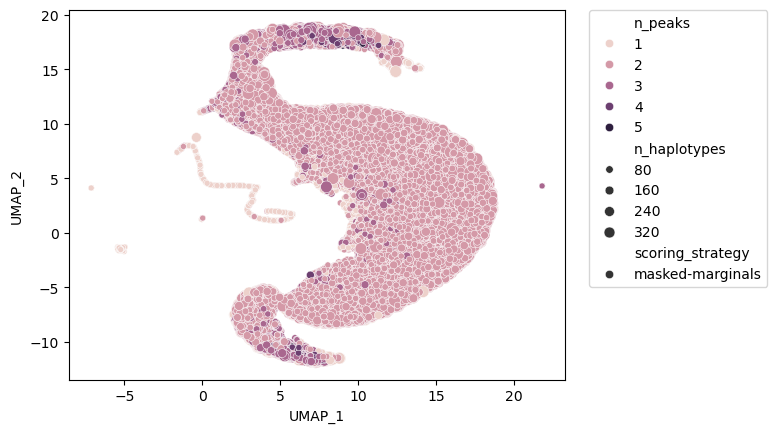

In [5]:
ecdf_umap_df = pd.DataFrame(embedding, 
                            index=vep_ecdf_pivot.index, 
                            columns=[f'UMAP_{i+1}' for i in range(embedding.shape[1])]
                            ).reset_index()

print(ecdf_umap_df.head())


import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(data=ecdf_umap_df,
                x='UMAP_1',
                y='UMAP_2',
                size='n_haplotypes',
                hue='n_peaks',
                style='scoring_strategy',
                )
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)


In [ ]:
import plotly.express as px

fig = px.scatter(ecdf_umap_df.sort_values('n_peaks', ascending=True),
                 x='UMAP_1',
                 y='UMAP_2',
                 color='n_peaks',
                 size='n_haplotypes',
                 size_max=5,
                 symbol='scoring_strategy',
                 hover_data=['model_location', 'protein', 'scoring_strategy'], 
                 hover_name='protein',
                 opacity=0.75)
# Reduce the height of the color bar
fig.update_layout(coloraxis_colorbar=dict(len=0.6))  # Reduce colorbar height to 60% of default
# Remove marker border
fig.update_traces(marker=dict(line=dict(width=0)))
fig.show()

#### Run hierarchical clustering on VEP KDE 

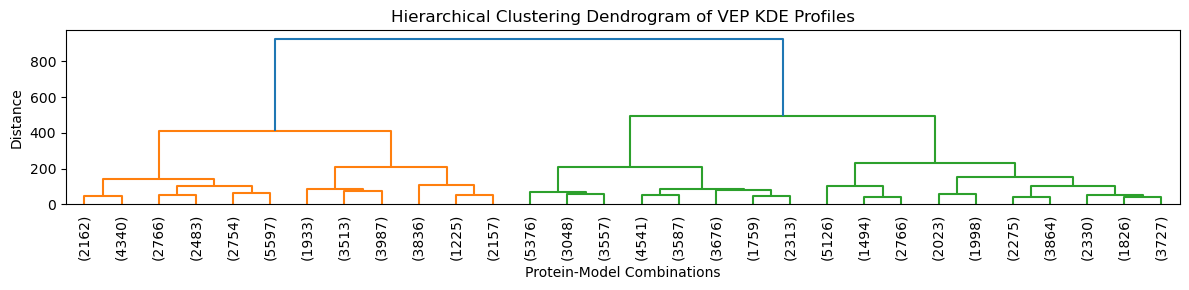

Number of clusters: 8
Cluster distribution: 1    20102
2     9433
3     7218
4    11981
5    15876
6     9386
7     4021
8    14022
Name: count, dtype: int64


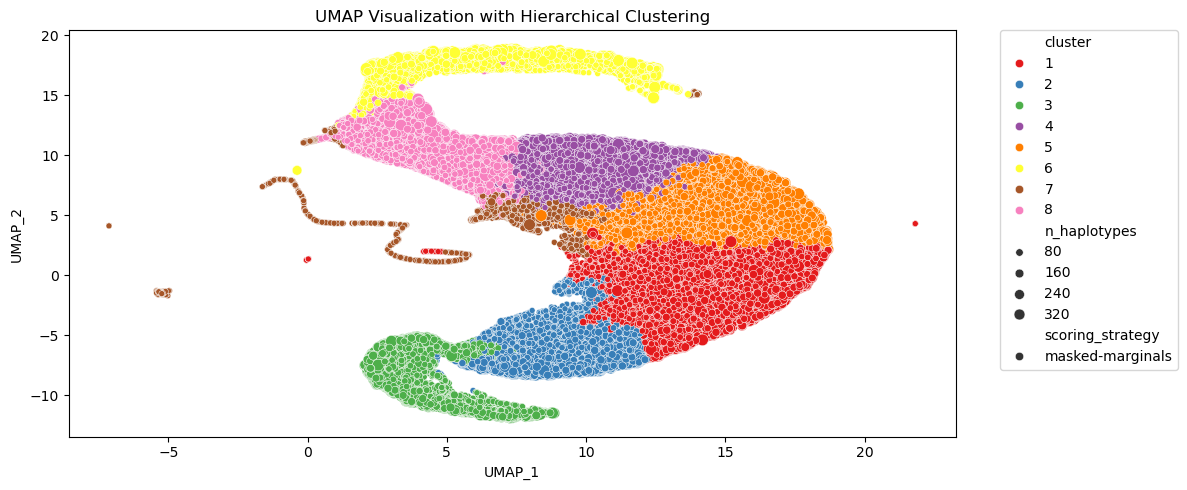

Cluster statistics:
index     n_peaks                       n_haplotypes                
             mean median min max  count         mean median min  max
cluster                                                             
1        2.006467    2.0   1   3  20102    53.994926   45.0   3  396
2        2.004876    2.0   1   4   9433    56.452560   45.0   4  396
3        2.202549    2.0   1   5   7218    74.894708   55.0   7  396
4        2.005843    2.0   1   3  11981    56.784576   47.0   5  396
5        2.012346    2.0   1   3  15876    53.671706   45.0   4  396
6        2.403260    2.0   1   5   9386    64.276902   50.0   5  396
7        1.437453    1.0   1   5   4021     9.168615    4.0   2  389
8        2.030880    2.0   1   4  14022    53.918842   45.0   4  396


In [16]:
# Perform hierarchical clustering on the VEP KDE data
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.preprocessing import StandardScaler


# vep_ecdf_pivot = vep_ecdf.pivot_table(
#     index=['model_location', 'protein', 'scoring_strategy', 'mutant', 'n_haplotypes', 'n_peaks'],
#     columns='index',
#     values='y'
# )

# Standardize the features
# scaler = StandardScaler()
# kde_scaled = scaler.fit_transform(vep_ecdf_pivot)

# Perform hierarchical clustering
Z = linkage(vep_ecdf_pivot, method='ward')

# Plot dendrogram
plt.figure(figsize=(12, 3))
dendrogram(Z, 
           truncate_mode='lastp',  # show only the last p merged clusters
           p=30,  # show only the last 30 merged clusters
           leaf_rotation=90.,
           leaf_font_size=10.)
plt.title('Hierarchical Clustering Dendrogram of VEP KDE Profiles')
plt.xlabel('Protein-Model Combinations')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()

# Cut the dendrogram to get clusters
n_clusters = 8  # You can adjust this based on the dendrogram
clusters = fcluster(Z, n_clusters, criterion='maxclust')

# Add cluster information to the original data
vep_ecdf_pivot['cluster'] = clusters
print(f"Number of clusters: {n_clusters}")
print(f"Cluster distribution: {pd.Series(clusters).value_counts().sort_index()}")

# Visualize clusters in UMAP space
groupby_cols = ['model_location', 'protein', 'scoring_strategy','mutant','n_haplotypes','n_peaks']
ecdf_umap_df['cluster'] = ecdf_umap_df.set_index(groupby_cols).index.map(
    vep_ecdf_pivot.reset_index().set_index(groupby_cols)['cluster']
)

plt.figure(figsize=(12, 5))
sns.scatterplot(data=ecdf_umap_df,
                x='UMAP_1',
                y='UMAP_2',
                hue='cluster',
                size='n_haplotypes',
                style='scoring_strategy',
                palette='Set1'
                )
plt.title('UMAP Visualization with Hierarchical Clustering')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
plt.tight_layout()
plt.show()

# Analyze cluster characteristics
cluster_stats = vep_ecdf_pivot.reset_index().groupby('cluster').agg({
    'n_peaks': ['mean', 'median', 'min', 'max', 'count'],
    'n_haplotypes': ['mean', 'median', 'min', 'max']
})
print("Cluster statistics:")
print(cluster_stats)


In [2]:
ecdf_umap_df_path = 'results/vep_ecdf_umap.tsv.gz'
if os.path.exists(ecdf_umap_df_path) and 'ecdf_umap_df' not in locals():
    print("Loading cached ECDF UMAP data")
    ecdf_umap_df = pd.read_csv(ecdf_umap_df_path, sep='\t')
else:
    ecdf_umap_df.to_csv(ecdf_umap_df_path, sep='\t')


Loading cached ECDF UMAP data


#### Gprofiler enrichment of each VEP modality


In [14]:
# Create a dictionary where keys are n_peaks and values are unique proteins
peak_protein_dict = {n_peak: list(set(proteins)) for n_peak, proteins in 
                     ecdf_umap_df.groupby(['n_peaks'])['protein'].apply(list).items()}

# Create a dictionary where keys are n_peaks and values are unique proteins
cluster_protein_dict = {cluster: list(set(proteins)) for cluster, proteins in 
                     ecdf_umap_df.groupby(['cluster'])['protein'].apply(list).items()}

In [15]:
from gprofiler import GProfiler

gp = GProfiler(return_dataframe=True)
gp_df = gp.profile(organism='hsapiens',
                   background=ecdf_umap_df['protein'].unique().tolist(),
                   query=peak_protein_dict)
print(gp_df.shape)

(61, 14)


In [20]:
print(gp_df.shape)

# gp_filt = gp_df.loc[(gp_df['significant']==True) & (gp_df['term_size'] < 1000)]
gp_filt = gp_df
print(gp_filt.shape)

(61, 16)
(61, 16)


In [24]:
gp_df

,source,native,name,p_value,significant,description,term_size,query_size,intersection_size,effective_domain_size,precision,recall,query,parents,cluster,neg_log_p_value
0,HP,HP:0000006,Autosomal dominant inheritance,1.817137e-08,True,A mode of inheritance that is observed for tra...,932,428,255,2116,0.595794,0.273605,1,[HP:0034345],1,7.740612
1,HP,HP:0001417,X-linked inheritance,4.183401e-08,True,A mode of inheritance that is observed for tra...,126,428,60,2116,0.140187,0.476190,1,[HP:0034345],1,7.378471
2,HP,HP:0001419,X-linked recessive inheritance,5.337896e-08,True,A mode of inheritance that is observed for rec...,93,428,49,2116,0.114486,0.526882,1,[HP:0001417],1,7.272630
3,HP,HP:0000006,Autosomal dominant inheritance,1.834212e-05,True,A mode of inheritance that is observed for tra...,932,386,225,2116,0.582902,0.241416,4,[HP:0034345],4,4.736550
4,REAC,REAC:R-HSA-162582,Signal Transduction,3.535817e-05,True,Signal Transduction,404,428,128,2116,0.299065,0.316832,1,[REAC:0000000],1,4.451510
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56,HP,HP:0025031,Abnormality of the digestive system,3.529123e-02,True,Abnormality of the digestive system,1379,386,292,2116,0.756477,0.211748,4,[HP:0000118],4,1.452333
57,TF,TF:M10112_1,Factor: Miz-1; motif: NNRGGWGGGGGAGGGGMRR; mat...,3.556584e-02,True,Factor: Miz-1; motif: NNRGGWGGGGGAGGGGMRR; mat...,520,428,145,2116,0.338785,0.278846,1,[TF:M10112],1,1.448967
58,GO:BP,GO:0048519,negative regulation of biological process,4.179942e-02,True,"""Any process that stops, prevents, or reduces ...",797,428,205,2116,0.478972,0.257215,1,"[GO:0008150, GO:0050789]",1,1.378830
59,REAC,REAC:R-HSA-166520,Signaling by NTRKs,4.504222e-02,True,Signaling by NTRKs,24,428,16,2116,0.037383,0.666667,1,[REAC:R-HSA-9006934],1,1.346380


   source             native  \
0      HP         HP:0000006   
1      HP         HP:0001417   
2      HP         HP:0001419   
3      HP         HP:0000006   
4    REAC  REAC:R-HSA-162582   
..    ...                ...   
56     HP         HP:0025031   
57     TF        TF:M10112_1   
58  GO:BP         GO:0048519   
59   REAC  REAC:R-HSA-166520   
60  GO:BP         GO:0007275   

                                                 name       p_value  \
0                      Autosomal dominant inheritance  1.817137e-08   
1                                X-linked inheritance  4.183401e-08   
2                      X-linked recessive inheritance  5.337896e-08   
3                      Autosomal dominant inheritance  1.834212e-05   
4                                 Signal Transduction  3.535817e-05   
..                                                ...           ...   
56                Abnormality of the digestive system  3.529123e-02   
57  Factor: Miz-1; motif: NNRGGWGGGGGAGGGGMRR; 

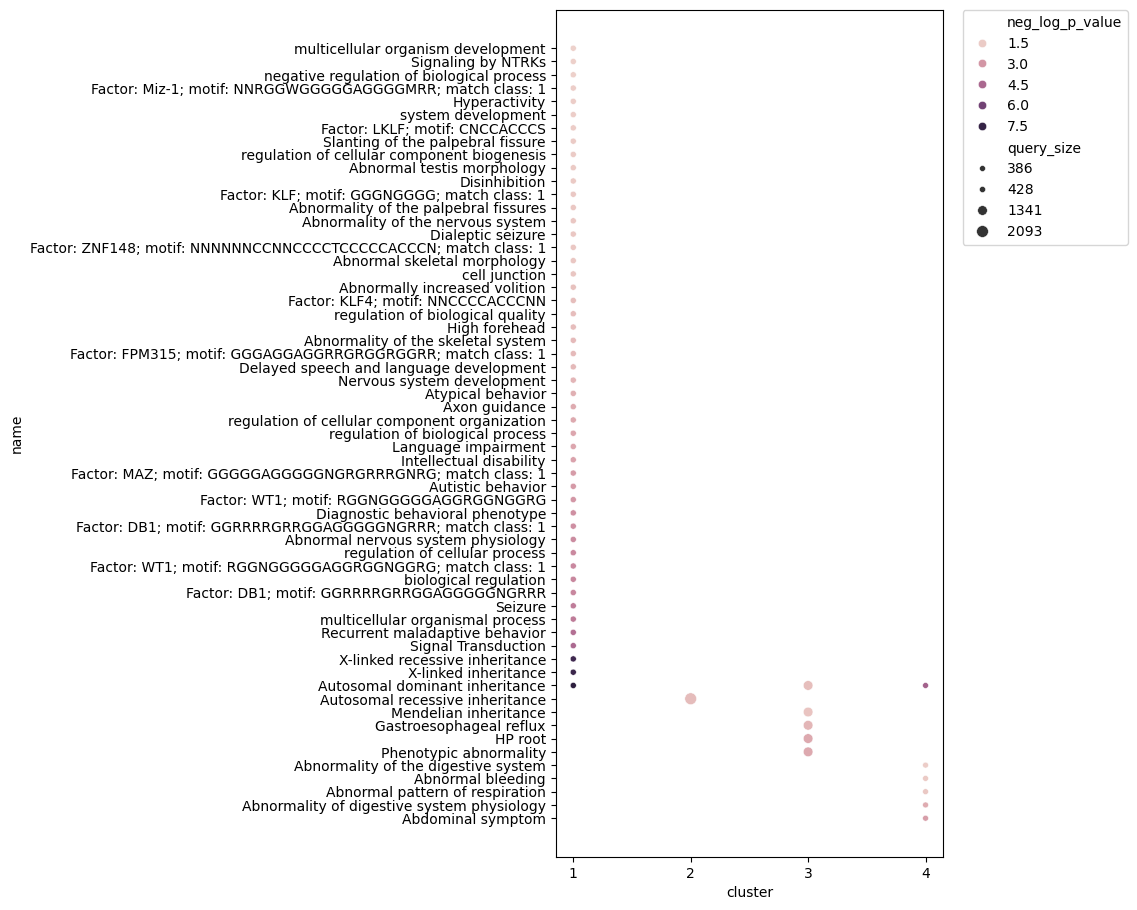

In [32]:

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
gp_df['cluster'] = gp_df['query'].astype(int).astype(str)
top_n = None
if top_n is not None:
    gp_top = gp_filt.groupby('query').head(top_n)
else:
    gp_top = gp_filt

gp_df['neg_log_p_value'] = -np.log10(gp_df['p_value'])
print(gp_top)

plt.figure(figsize=(5, 11))
# Convert cluster to categorical with ordered categories to ensure proper ordering
ordered_clusters = [str(i) for i in range(1, max(gp_df['cluster'].astype(int).unique())+1)]  # Clusters 1-10 in order
plot_data = gp_df[gp_df['name'].isin(gp_top['name'])].sort_values(['cluster','neg_log_p_value'])
plot_data['cluster'] = pd.Categorical(plot_data['cluster'], categories=ordered_clusters, ordered=True)

sns.scatterplot(data=plot_data,
            x='cluster',
            y='name',
            hue='neg_log_p_value',
            size='query_size',
            )

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
plt.show()



### Benign/Pathogenic Ratio

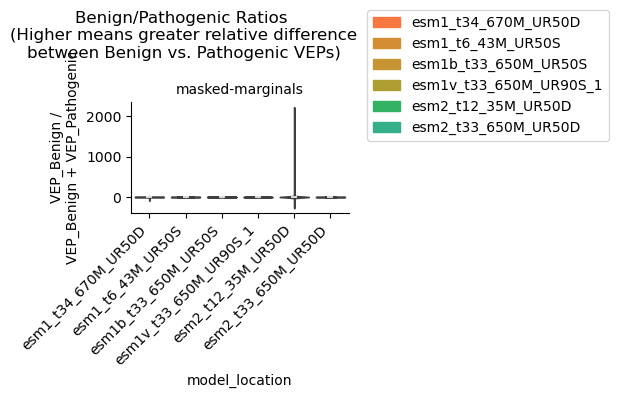

In [86]:
vep_pbratios = va.plot_vep_bpratios(vep_df,
                                     y=['benign_path_ratio','benign_path_ratio_strict'][1]
                                     )

## Plots: Single Protein

### Violin plots: wt-marginals

In [98]:
va.plot_vep_violin(vep_df, 
                #    model_location="esm2_t33_650M_UR50D",
                   max_proteins=1,
                   max_models=1,
                   save_path="results/plots/vep_violin;esm2_t33_650M_UR50D;wt-marginals.png",
                   scoring_strategy="wt-marginals")

Filtered 0.5% of rows with NAs in col 'VEP'


ValueError: Number of rows must be a positive integer, not 0

<Figure size 600x0 with 0 Axes>

### Violin plots: masked-marginals

Filtered 0.7% of rows with NAs in col 'VEP'


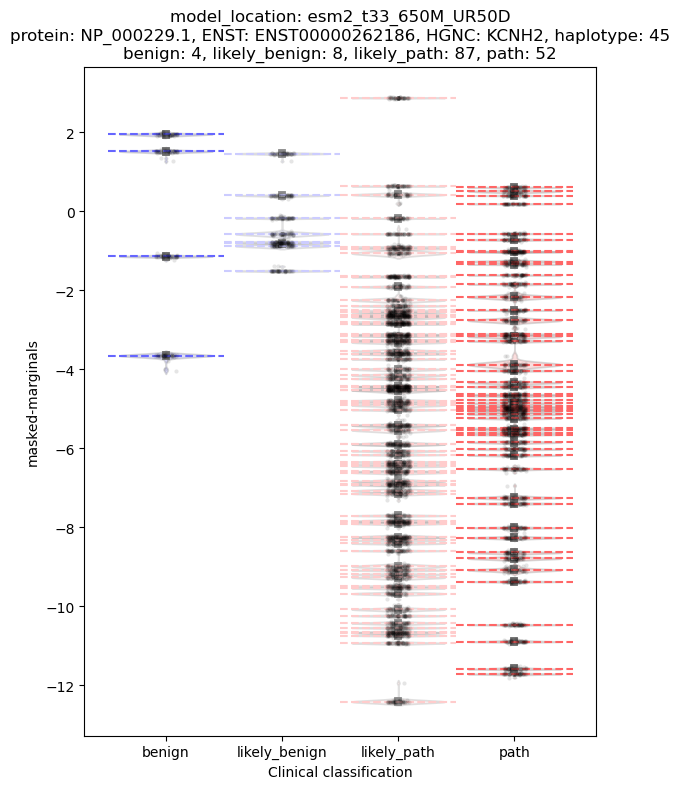

In [196]:
va.plot_vep_violin(vep_df, 
                   model_location="esm2_t33_650M_UR50D",
                    max_proteins=1,
                    max_models=1,
                    save_path="results/plots/vep_violin;esm2_t33_650M_UR50D;masked-marginals.png",
                    scoring_strategy="masked-marginals")

### Haplotype Representiveness

In [88]:
vep_df['VEP_percentile'] = vep_df.groupby(['model_location', 'protein', 'mutant','scoring_strategy'])['VEP'].rank(pct=True)
vep_df[['VEP_percentile']]

,VEP_percentile
0,0.397059
1,0.519608
2,0.447619
3,0.495238
4,0.504762
...,...
3861747,0.400000
3861748,0.288889
3861749,0.733333
3861750,0.288889


### Reference Representativeness: Percentiles

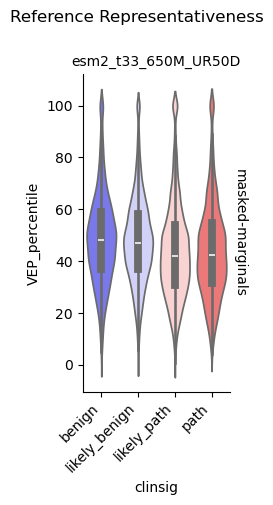

In [12]:
va.plot_vep_percentiles(vep_df, 
                        col='model_location',
                        row='scoring_strategy',
                        height=5,
                        aspect=.5,
                        save_path="results/plots/vep_percentiles.png")

In [93]:
vep_df.loc[vep_df['is_ref']==True]['VEP_percentile'].describe()

count    68385.000000
mean         0.483787
std          0.174238
min          0.007042
25%          0.369048
50%          0.473684
75%          0.581818
max          1.000000
Name: VEP_percentile, dtype: float64

In [ ]:
# Get genes where the reference is the LEAST representitive

In [34]:
vep_df.loc[:,'VEP_percentile_deivation'] = abs(vep_df['VEP_percentile'] - 50)
most_deviant_ref = vep_df.loc[vep_df['is_ref']==True].groupby(['model_location', 'scoring_strategy','protein']).agg({'VEP_percentile_deivation':['count','min','max','mean','median']}).sort_values(('VEP_percentile_deivation','mean'), ascending=False).reset_index()
most_deviant_ref.head(10)

model_location  scoring_strategy      protein  \
                                                        
0  esm2_t33_650M_UR50D  masked-marginals  NP_000052.1   
1  esm2_t33_650M_UR50D  masked-marginals  NP_000107.1   
2  esm2_t33_650M_UR50D  masked-marginals  NP_005667.2   
3  esm2_t33_650M_UR50D  masked-marginals  NP_006297.2   
4  esm2_t33_650M_UR50D  masked-marginals  NP_006512.2   
5  esm2_t33_650M_UR50D  masked-marginals  NP_005620.1   
6  esm2_t33_650M_UR50D  masked-marginals  NP_004484.1   
7  esm2_t33_650M_UR50D  masked-marginals  NP_821133.1   
8  esm2_t33_650M_UR50D  masked-marginals  NP_004178.2   
9  esm2_t33_650M_UR50D  masked-marginals  NP_036412.1   

  VEP_percentile_deivation                           
                     count   min   max  mean median  
0                       76  50.0  50.0  50.0   50.0  
1                       20  50.0  50.0  50.0   50.0  
2                       10  50.0  50.0  50.0   50.0  
3                       79  50.0  50.0  50.0   50.0  
4                       14  50.0  50.0  50.0   50.0  
5                       57  50.0  50.0  50.0   50.0  
6                       14  50.0  50.0  50.0   50.0  
7                       24  50.0  50.0  50.0   50.0  
8                       65  50.0  50.0  50.0   50.0  
9                       10  50.0  50.0  50.0   50.0

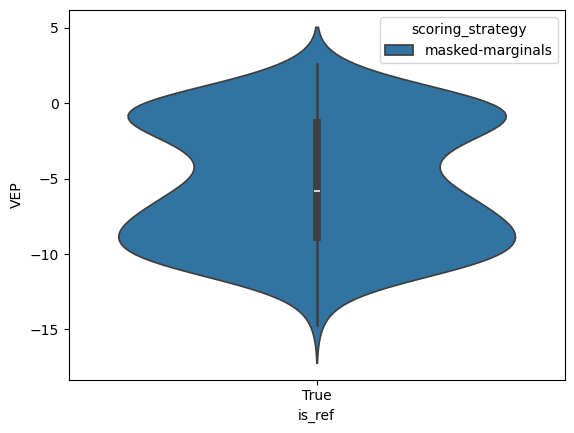

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a FacetGrid to facet by scoring_strategy
g = sns.violinplot(data=vep_df.loc[vep_df['protein'].isin(most_deviant_ref['protein'].unique()[:12])],
                   x='is_ref',
                   y='VEP',
                   hue='scoring_strategy',
                   )
plt.show()

In [46]:
from gprofiler import GProfiler
gp = GProfiler(return_dataframe=True)
gp_df = gp.profile(organism='hsapiens',
           background=vep_files['protein'].unique().tolist(),
           query=most_deviant_ref['protein'].unique().tolist()[:50]
           )
gp_df


,source,native,name,p_value,significant,description,term_size,query_size,intersection_size,effective_domain_size,precision,recall,query,parents
0,HP,HP:0001417,X-linked inheritance,0.000516,True,A mode of inheritance that is observed for tra...,148,50,17,2142,0.34,0.114865,query_1,[HP:0034345]
1,HP,HP:0001419,X-linked recessive inheritance,0.003431,True,A mode of inheritance that is observed for rec...,109,50,14,2142,0.28,0.128440,query_1,[HP:0001417]


## Precision-Recall 

### Add edit distance metrics

In [94]:
# Add the number of edits (variants relative to the reference) per haplotype
vep_df = utils.add_edits(vep_df)

# Scale edits by protein sequence length
seq_lens = {seq:len(seq) for seq in vep_df['protein_sequence']}
vep_df['protein_sequence_len'] = vep_df['protein_sequence'].map(seq_lens)
vep_df['edits_scaled'] = vep_df['edits'] / vep_df['protein_sequence_len']
vep_df['edits_clipped'] = vep_df['edits'].clip(upper=20)
vep_df.loc[:,'edits_scaled_rounded'] = vep_df['edits_scaled'].round(3)

# vep_df['edits_scaled_quartiles'] = pd.qcut(vep_df.groupby(['protein','mutant'])['edits_scaled'], q=10, labels=False)
# vep_df['edits_scaled_quartiles'].value_counts()

Filter to only include variants with high-confidence annotations.

In [95]:
print(vep_df.groupby("clinsig")['CLNREVSTAT'].value_counts())

vep_qc = vep_df.loc[(vep_df['clinsig'].isin(["path","benign"])) &\
                    (vep_df['CLNREVSTAT'].isin(['reviewed_by_expert_panel','practice_guideline']))]

clinsig        CLNREVSTAT                                          
benign         criteria_provided,_single_submitter                     333452
               criteria_provided,_multiple_submitters,_no_conflicts    259188
               reviewed_by_expert_panel                                 67894
likely_benign  criteria_provided,_single_submitter                     927813
               criteria_provided,_multiple_submitters,_no_conflicts    513666
               reviewed_by_expert_panel                                 13291
likely_path    criteria_provided,_single_submitter                     723754
               criteria_provided,_multiple_submitters,_no_conflicts    437389
               reviewed_by_expert_panel                                 43397
path           criteria_provided,_single_submitter                     307734
               criteria_provided,_multiple_submitters,_no_conflicts    132227
               reviewed_by_expert_panel                                 97

In [96]:
vep_pr = va.compute_precision_recall(vep_qc,
                                     groupby_cols = ['model_location', 'scoring_strategy',
                                                     'protein',
                                                     'is_ref', 
                                                     'protein_sequence_len', 'haplotype',
                                                    #  'edits',
                                                    'edits_scaled_rounded'
                                                     ],
                                     agg_cols = ['protein','protein_sequence_len', 'haplotype'],
                                     x='VEP',
                                     y='DMS_bin_score')


Binarizing pathogenic vs benign labels


Computing precision and recall:   0%|          | 0/3639 [00:00<?, ?it/s]

In [99]:
print(vep_pr.shape)
vep_pr.head()

(43, 9)


,scoring_strategy,model_location,is_ref,edits_scaled_rounded,accuracy,auc,coef,intercept,n_samples
0,masked-marginals,esm1_t34_670M_UR50D,False,0.001,0.869699,0.862301,-0.418116,-2.301909,17097
1,masked-marginals,esm1_t34_670M_UR50D,False,0.002,0.951569,0.952633,-0.675808,-3.290716,4298
2,masked-marginals,esm1_t34_670M_UR50D,False,0.003,0.925488,0.828541,-0.700510,-3.176116,7567
3,masked-marginals,esm1_t34_670M_UR50D,False,0.004,1.000000,1.000000,-0.335300,-1.973312,104
4,masked-marginals,esm1_t34_670M_UR50D,False,0.005,0.966387,1.000000,-0.986889,-5.020192,328


In [101]:
vep_pr_ref_only = va.compute_precision_recall(vep_qc.loc[vep_qc['is_ref']==True],
                                     groupby_cols = ['model_location', 'scoring_strategy','protein'],
                                     agg_cols = ['protein'],
                                     x='VEP',
                                     y='DMS_bin_score')
vep_pr_ref_only['group'] = 'Ref only'
vep_pr_all = va.compute_precision_recall(vep_qc,
                                     groupby_cols = ['model_location', 'scoring_strategy','protein'],
                                     agg_cols = ['protein'],
                                     x='VEP',
                                     y='DMS_bin_score')
vep_pr_all['group'] = 'All'
vep_pr_grouped = pd.concat([vep_pr_ref_only, vep_pr_all])
vep_pr_grouped


Binarizing pathogenic vs benign labels


Computing precision and recall:   0%|          | 0/67 [00:00<?, ?it/s]

Binarizing pathogenic vs benign labels


Computing precision and recall:   0%|          | 0/69 [00:00<?, ?it/s]

,model_location,scoring_strategy,accuracy,auc,coef,intercept,n_samples,group
0,esm1_t34_670M_UR50D,masked-marginals,0.922827,0.923887,-0.626985,-2.935390,492,Ref only
1,esm1_t6_43M_UR50S,masked-marginals,0.867102,0.750367,-0.562018,-1.214258,196,Ref only
2,esm1b_t33_650M_UR50S,masked-marginals,0.941176,0.951724,-1.035698,-6.061322,34,Ref only
3,esm1v_t33_650M_UR90S_1,masked-marginals,0.970588,0.944828,-0.889119,-3.404146,34,Ref only
4,esm2_t12_35M_UR50D,masked-marginals,0.810120,0.787691,-0.339665,-0.364349,586,Ref only
5,esm2_t33_650M_UR50D,masked-marginals,0.937364,0.933678,-0.729286,-3.091472,196,Ref only
0,esm1_t34_670M_UR50D,masked-marginals,0.932224,0.923185,-0.998520,-6.114943,30296,All
1,esm1_t6_43M_UR50S,masked-marginals,0.867074,0.750241,-0.598848,-1.305849,19366,All
2,esm1b_t33_650M_UR50S,masked-marginals,0.940107,0.949987,-1.409723,-8.620766,1870,All
3,esm1v_t33_650M_UR90S_1,masked-marginals,0.970588,0.945562,-1.064717,-4.330592,1870,All


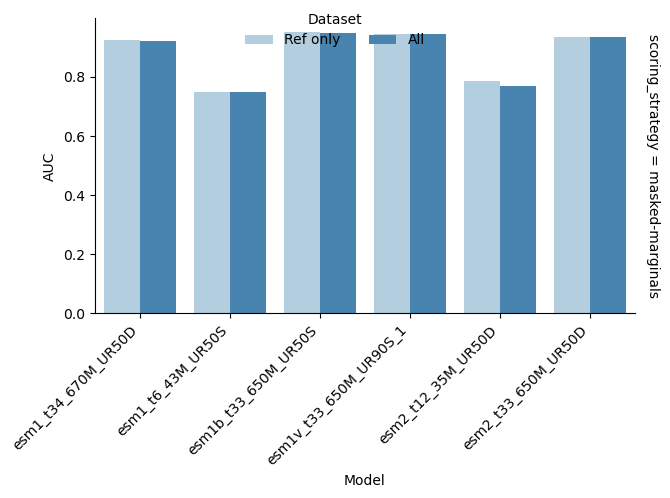

In [102]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a FacetGrid to facet by scoring_strategy
g = sns.FacetGrid(data=vep_pr_grouped,
                  row="scoring_strategy",
                  margin_titles=True,
                  height=5, 
                  aspect=1)

# Map the barplot to each facet
g.map_dataframe(sns.barplot, 
                x="model_location", 
                y="auc", 
                hue="group",
                palette='Blues')

# Fix x-axis labels - apply rotation to each subplot
for ax in g.axes.flat:
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

# Adjust layout and add titles
g.set_axis_labels("Model", "AUC")
# _rm_subplot_prefixes(g)

# Add a legend for the hue variable
g.add_legend(title="Dataset", loc='upper center', ncol=2)

plt.tight_layout()
plt.show()

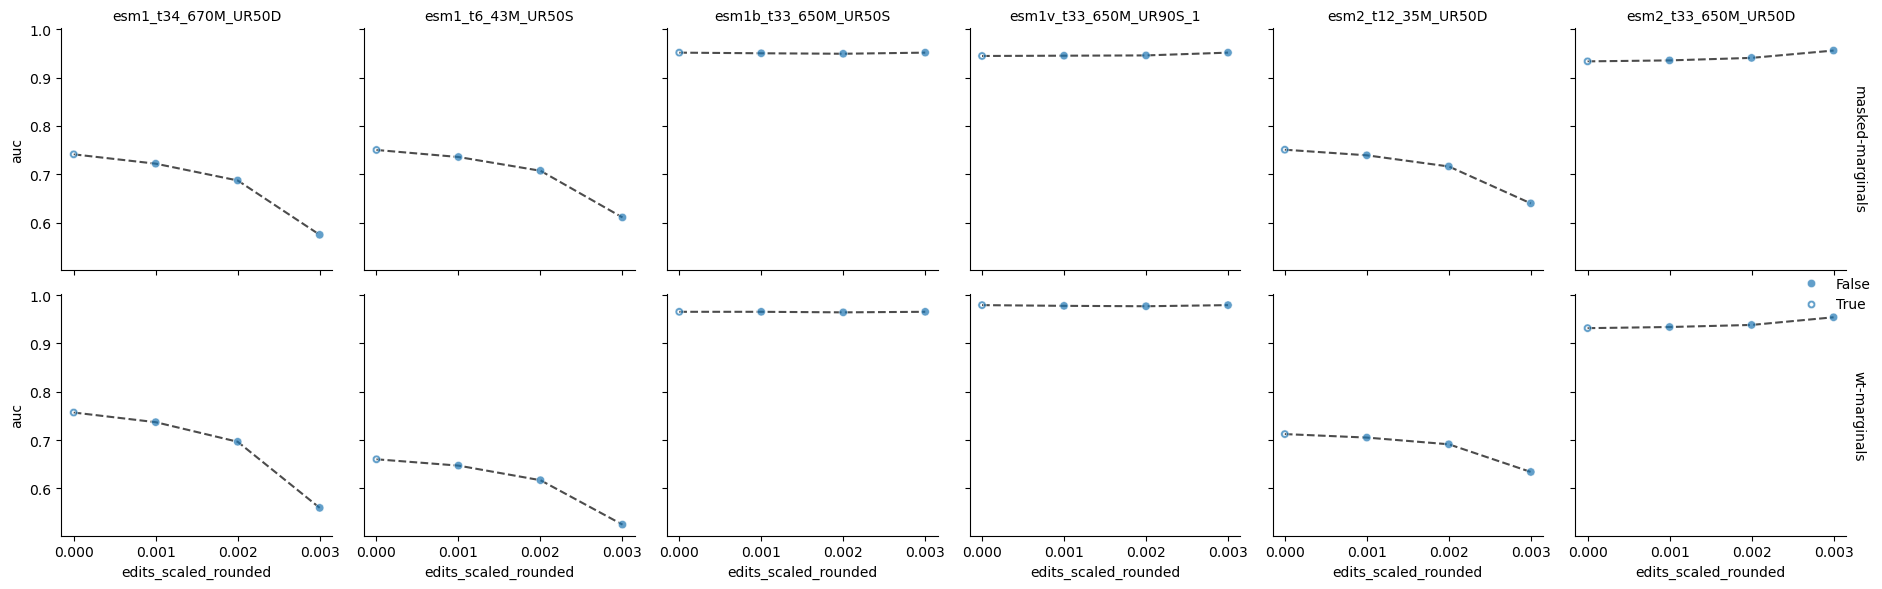

In [26]:
va.plot_auc_by_edits(vep_pr, #vep_pr.loc[vep_pr['edits'] < 20],
                      col="model_location",
                      row="scoring_strategy", 
                      style="is_ref",
                     x="edits_scaled_rounded", 
                     save_path="results/plots/vep_pr_auc_by_edits.png")

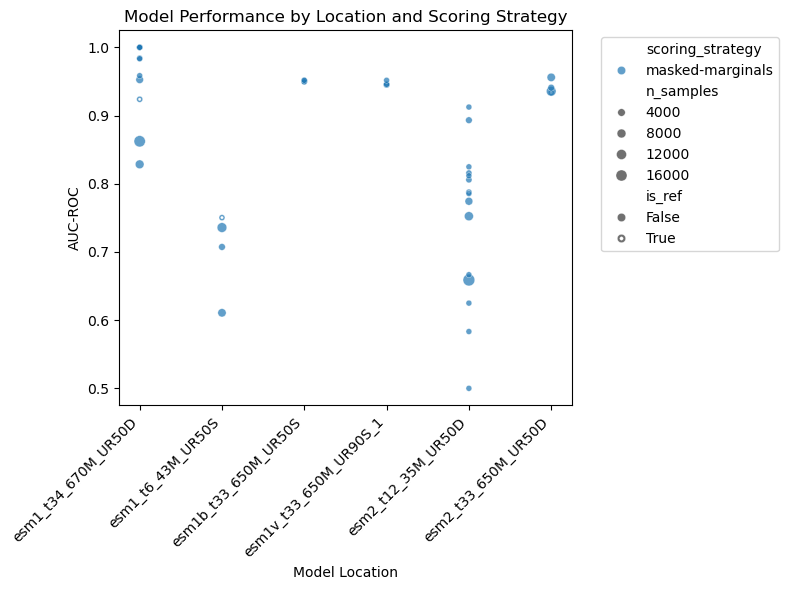

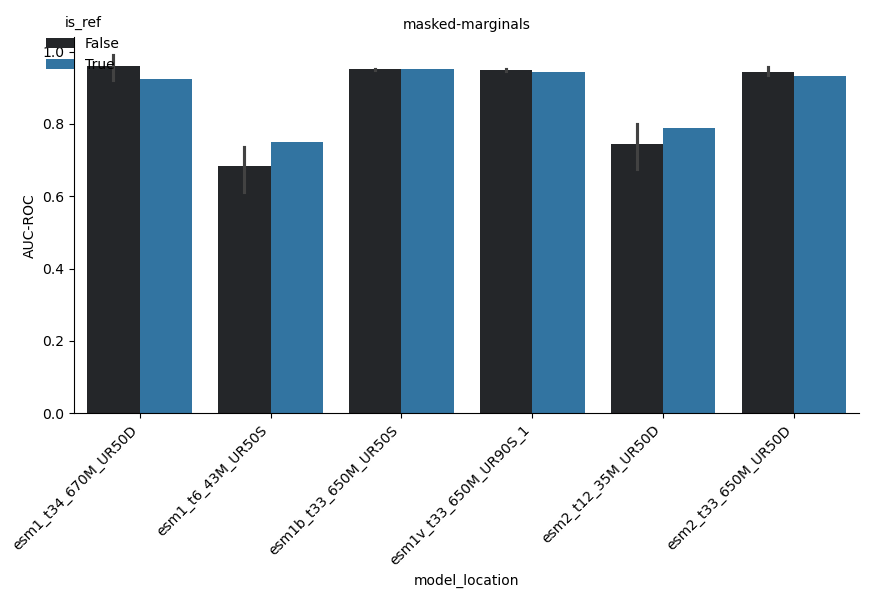

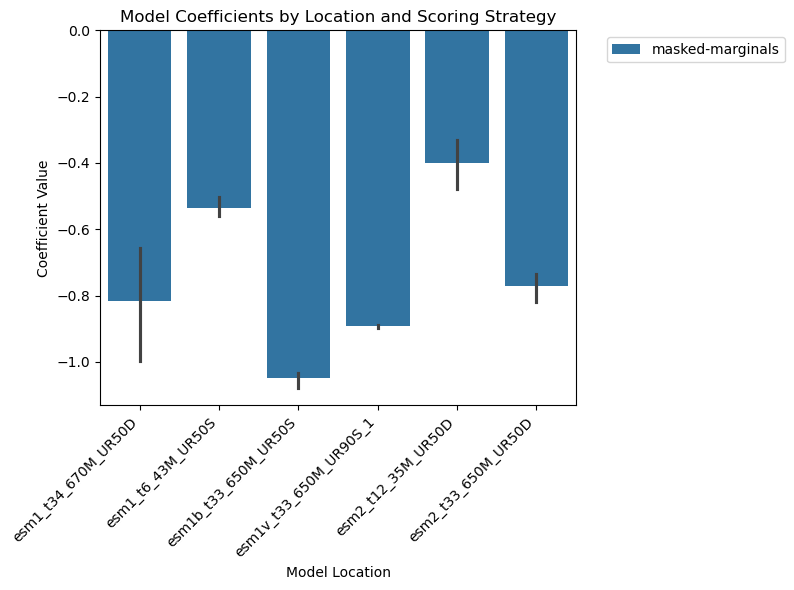

In [103]:
va.plot_precision_recall(vep_pr,
                         style='is_ref',
                         
                         save_path="results/plots/precision_recall.png",
                         hue='scoring_strategy')

### Pairwise correlations between haplotypes
Compute pairwise correlations between all haplotypes for a given protein.

In [105]:
# Group by protein and pivot to get haplotype columns
tqdm.pandas(desc="Pivoting VEP")
vep_pivot = vep_df.groupby('protein').progress_apply(lambda x: pd.pivot_table(x,
                                                                    index=['protein', 'mutant'],
                                                                    columns='edits_clipped',
                                                                    values='VEP',
                                                                    # Only include haplotypes for this protein
                                                                    dropna=True))
vep_pivot


Pivoting VEP:   0%|          | 0/1772 [00:00<?, ?it/s]

edits_clipped                          0          1          2         20  3   \
protein     protein     mutant                                                  
NP_000007.1 NP_000007.1 A113D   -7.708576  -7.715696  -7.693262 -7.758820 NaN   
                        A113T   -4.232880  -4.237339  -4.239253 -4.131114 NaN   
                        A136V   -2.095088  -2.079986  -2.093937 -2.206535 NaN   
                        A165T   -2.368854  -2.382868  -2.369235 -2.368831 NaN   
                        A205P   -5.687437  -5.676813  -5.668174 -5.591449 NaN   
...                                   ...        ...        ...       ...  ..   
NP_998885.1 NP_998885.1 R15L    -9.027851  -8.889543  -9.132408       NaN NaN   
                        S59L   -19.177984 -19.245420 -18.696195       NaN NaN   
                        S77G    -1.477943  -1.495848  -1.485637       NaN NaN   
                        T90P     3.208157   3.182882   2.964261       NaN NaN   
                        Y135H    2.782606   2.666708   2.839180       NaN NaN   

edits_clipped                   4   5   6   7   8   10  11  19  18  14  17  \
protein     protein     mutant                                               
NP_000007.1 NP_000007.1 A113D  NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN   
                        A113T  NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN   
                        A136V  NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN   
                        A165T  NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN   
                        A205P  NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN   
...                             ..  ..  ..  ..  ..  ..  ..  ..  ..  ..  ..   
NP_998885.1 NP_998885.1 R15L   NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN   
                        S59L   NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN   
                        S77G   NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN   
                        T90P   NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN   
                        Y135H  NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN   

edits_clipped                   12  9   16  13  15  
protein     protein     mutant                      
NP_000007.1 NP_000007.1 A113D  NaN NaN NaN NaN NaN  
                        A113T  NaN NaN NaN NaN NaN  
                        A136V  NaN NaN NaN NaN NaN  
                        A165T  NaN NaN NaN NaN NaN  
                        A205P  NaN NaN NaN NaN NaN  
...                             ..  ..  ..  ..  ..  
NP_998885.1 NP_998885.1 R15L   NaN NaN NaN NaN NaN  
                        S59L   NaN NaN NaN NaN NaN  
                        S77G   NaN NaN NaN NaN NaN  
                        T90P   NaN NaN NaN NaN NaN  
                        Y135H  NaN NaN NaN NaN NaN  

[45278 rows x 21 columns]

In [106]:
vep_pivot.index.get_level_values('mutant').value_counts()

# Calculate percentage of non-NA values for each row
pct_nonna = (vep_pivot.notna().sum(axis=0) / vep_pivot.shape[0] * 100).round(2)

pct_nonna.describe()


count     21.000000
mean      17.549524
std       32.147812
min        0.020000
25%        0.080000
50%        0.530000
75%       17.370000
max      100.000000
dtype: float64

In [107]:
vep_pivot.index.get_level_values(0).nunique()

1772

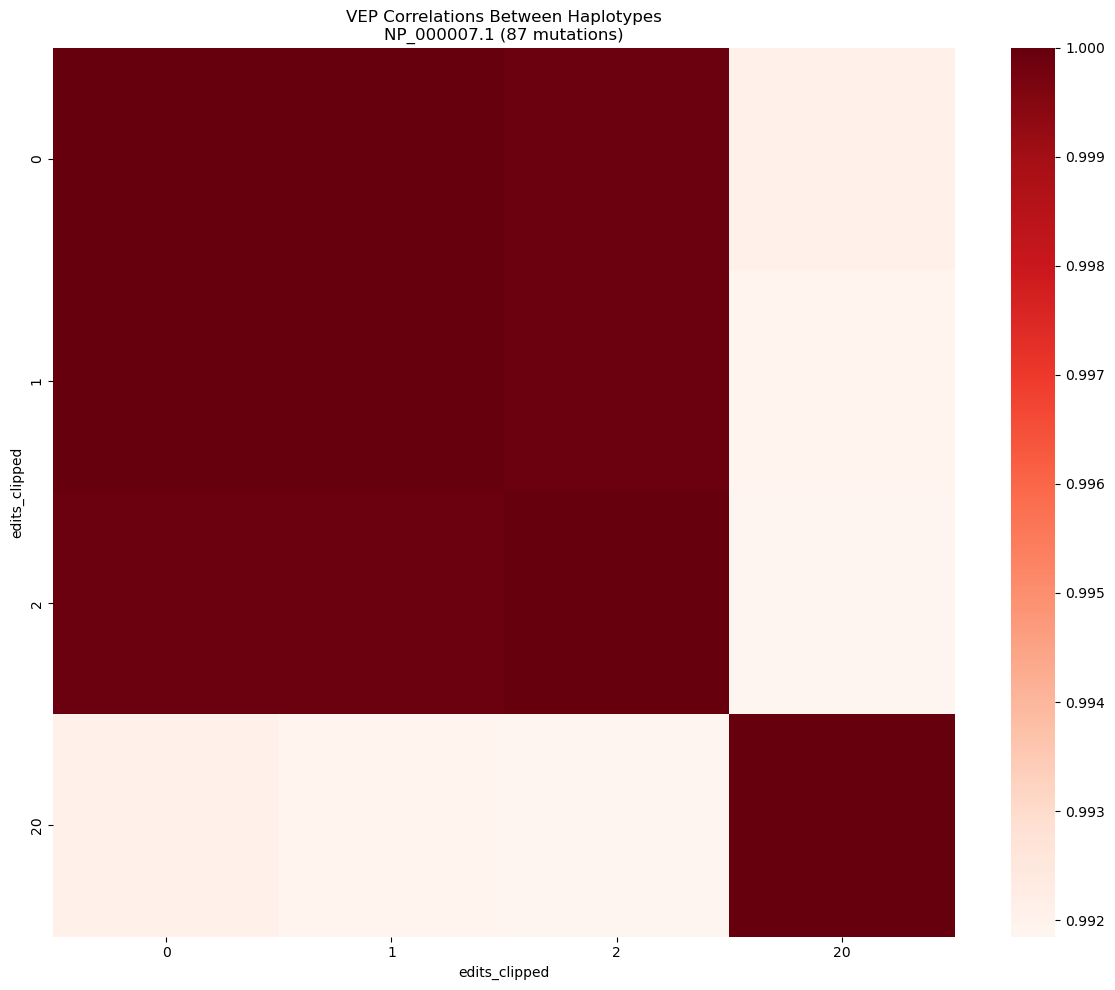

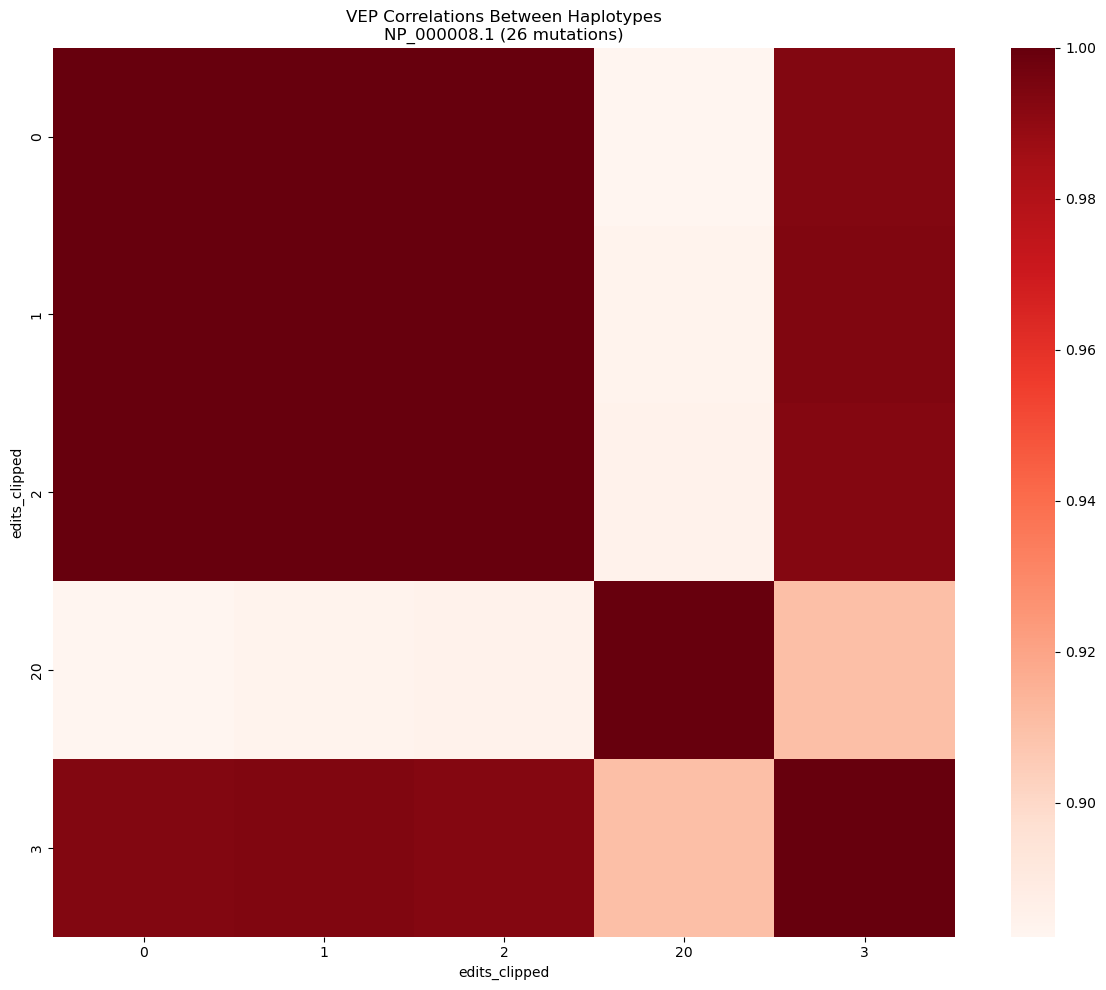

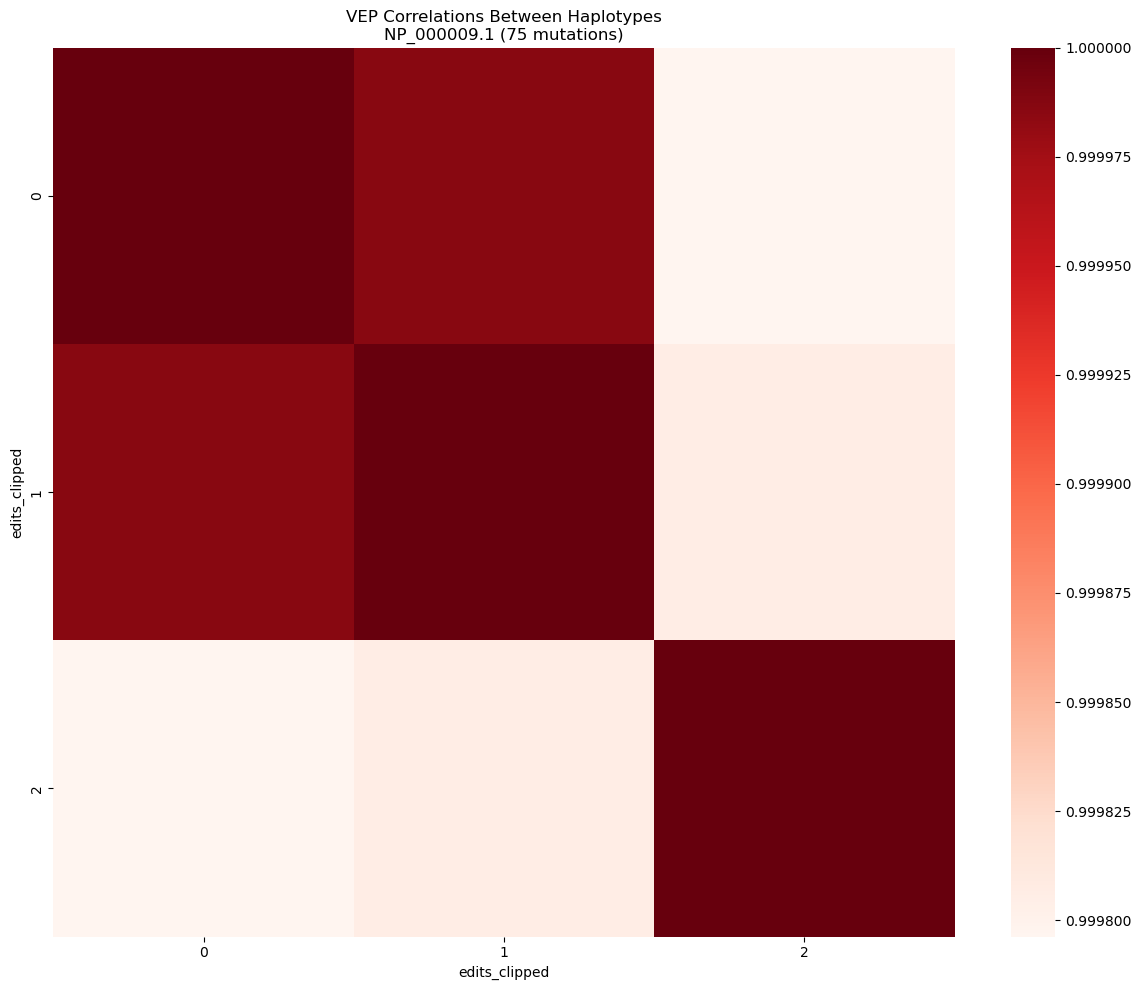

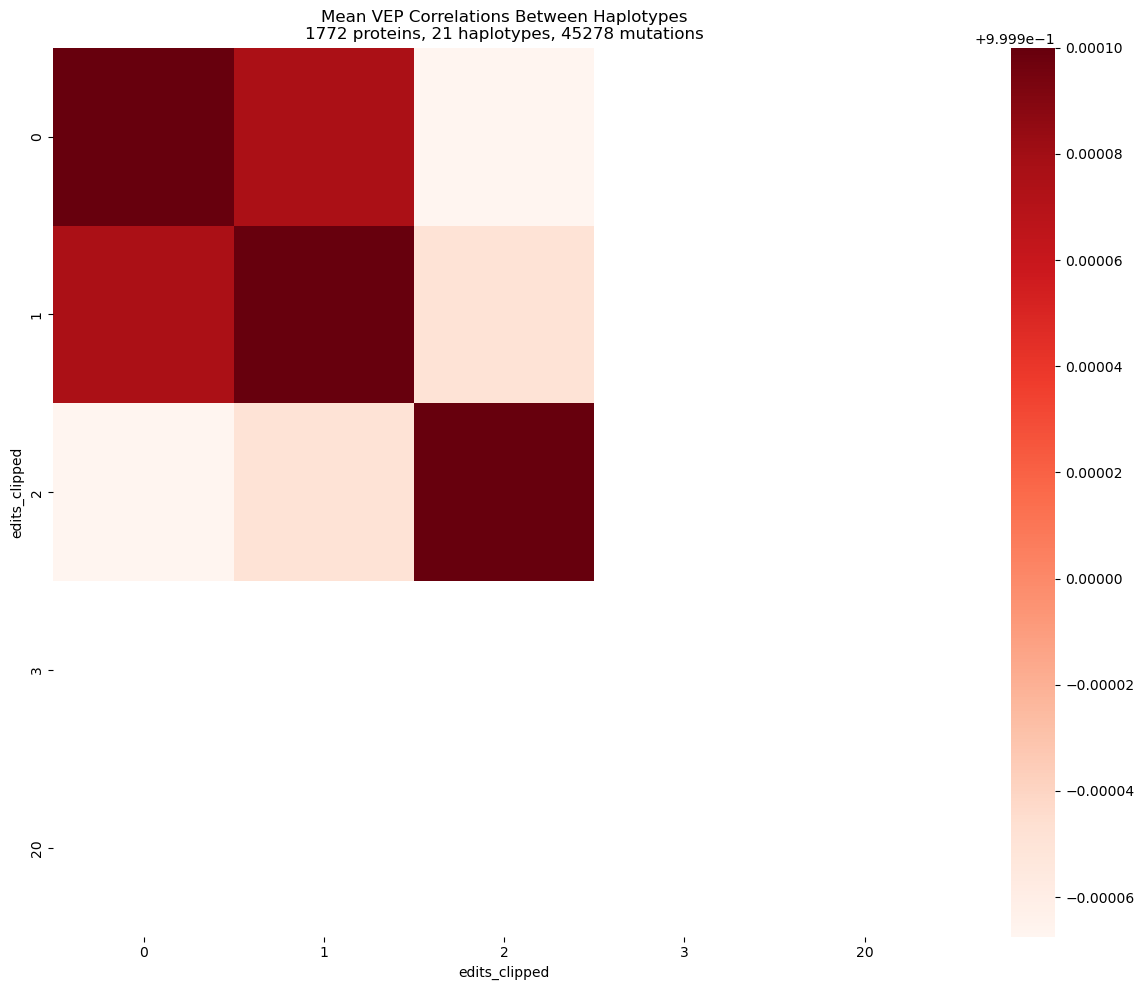

In [109]:
# Compute correlations within each protein
vep_corr = vep_pivot.groupby('protein').apply(lambda x: x.corr())
import matplotlib.pyplot as plt
import seaborn as sns
# Create list to store correlation matrices
corr_matrices = []

max_proteins = 3
# Get correlation matrix for each protein
for protein in vep_corr.index.get_level_values(0).unique()[:max_proteins]:
    corr_matrix = vep_corr.loc[protein]
    # Remove columns that are all NA
    corr_matrix = corr_matrix.dropna(axis=1, how='all')
    # Remove rows that are all NA 
    corr_matrix = corr_matrix.dropna(axis=0, how='all')
    plt.figure(figsize=(12,10))
    sns.heatmap(corr_matrix,
                cmap='Reds', 
                # center=vep_corr.mean().mean(),
                # vmin=vep_corr.min().min(),
                # vmax=vep_corr.max().max()
                )
    n_mutations = len(vep_pivot.loc[protein].index)
    plt.title(f'VEP Correlations Between Haplotypes\n{protein} ({n_mutations} mutations)')
    plt.tight_layout()
    plt.show()
    corr_matrices.append(corr_matrix)

# Calculate mean correlation matrix
mean_corr = sum(corr_matrices) / len(corr_matrices)

# Plot mean correlation heatmap
plt.figure(figsize=(12,10))
sns.heatmap(mean_corr,
            cmap='Reds',
            )
plt.title(f'Mean VEP Correlations Between Haplotypes\n{vep_pivot.index.get_level_values(0).nunique()} proteins, {len(vep_pivot.columns)} haplotypes, {len(vep_pivot.index)} mutations')
plt.tight_layout()
plt.show()
